# Data procesiong

Sheet 512: dropped 1 low-count slice(s)


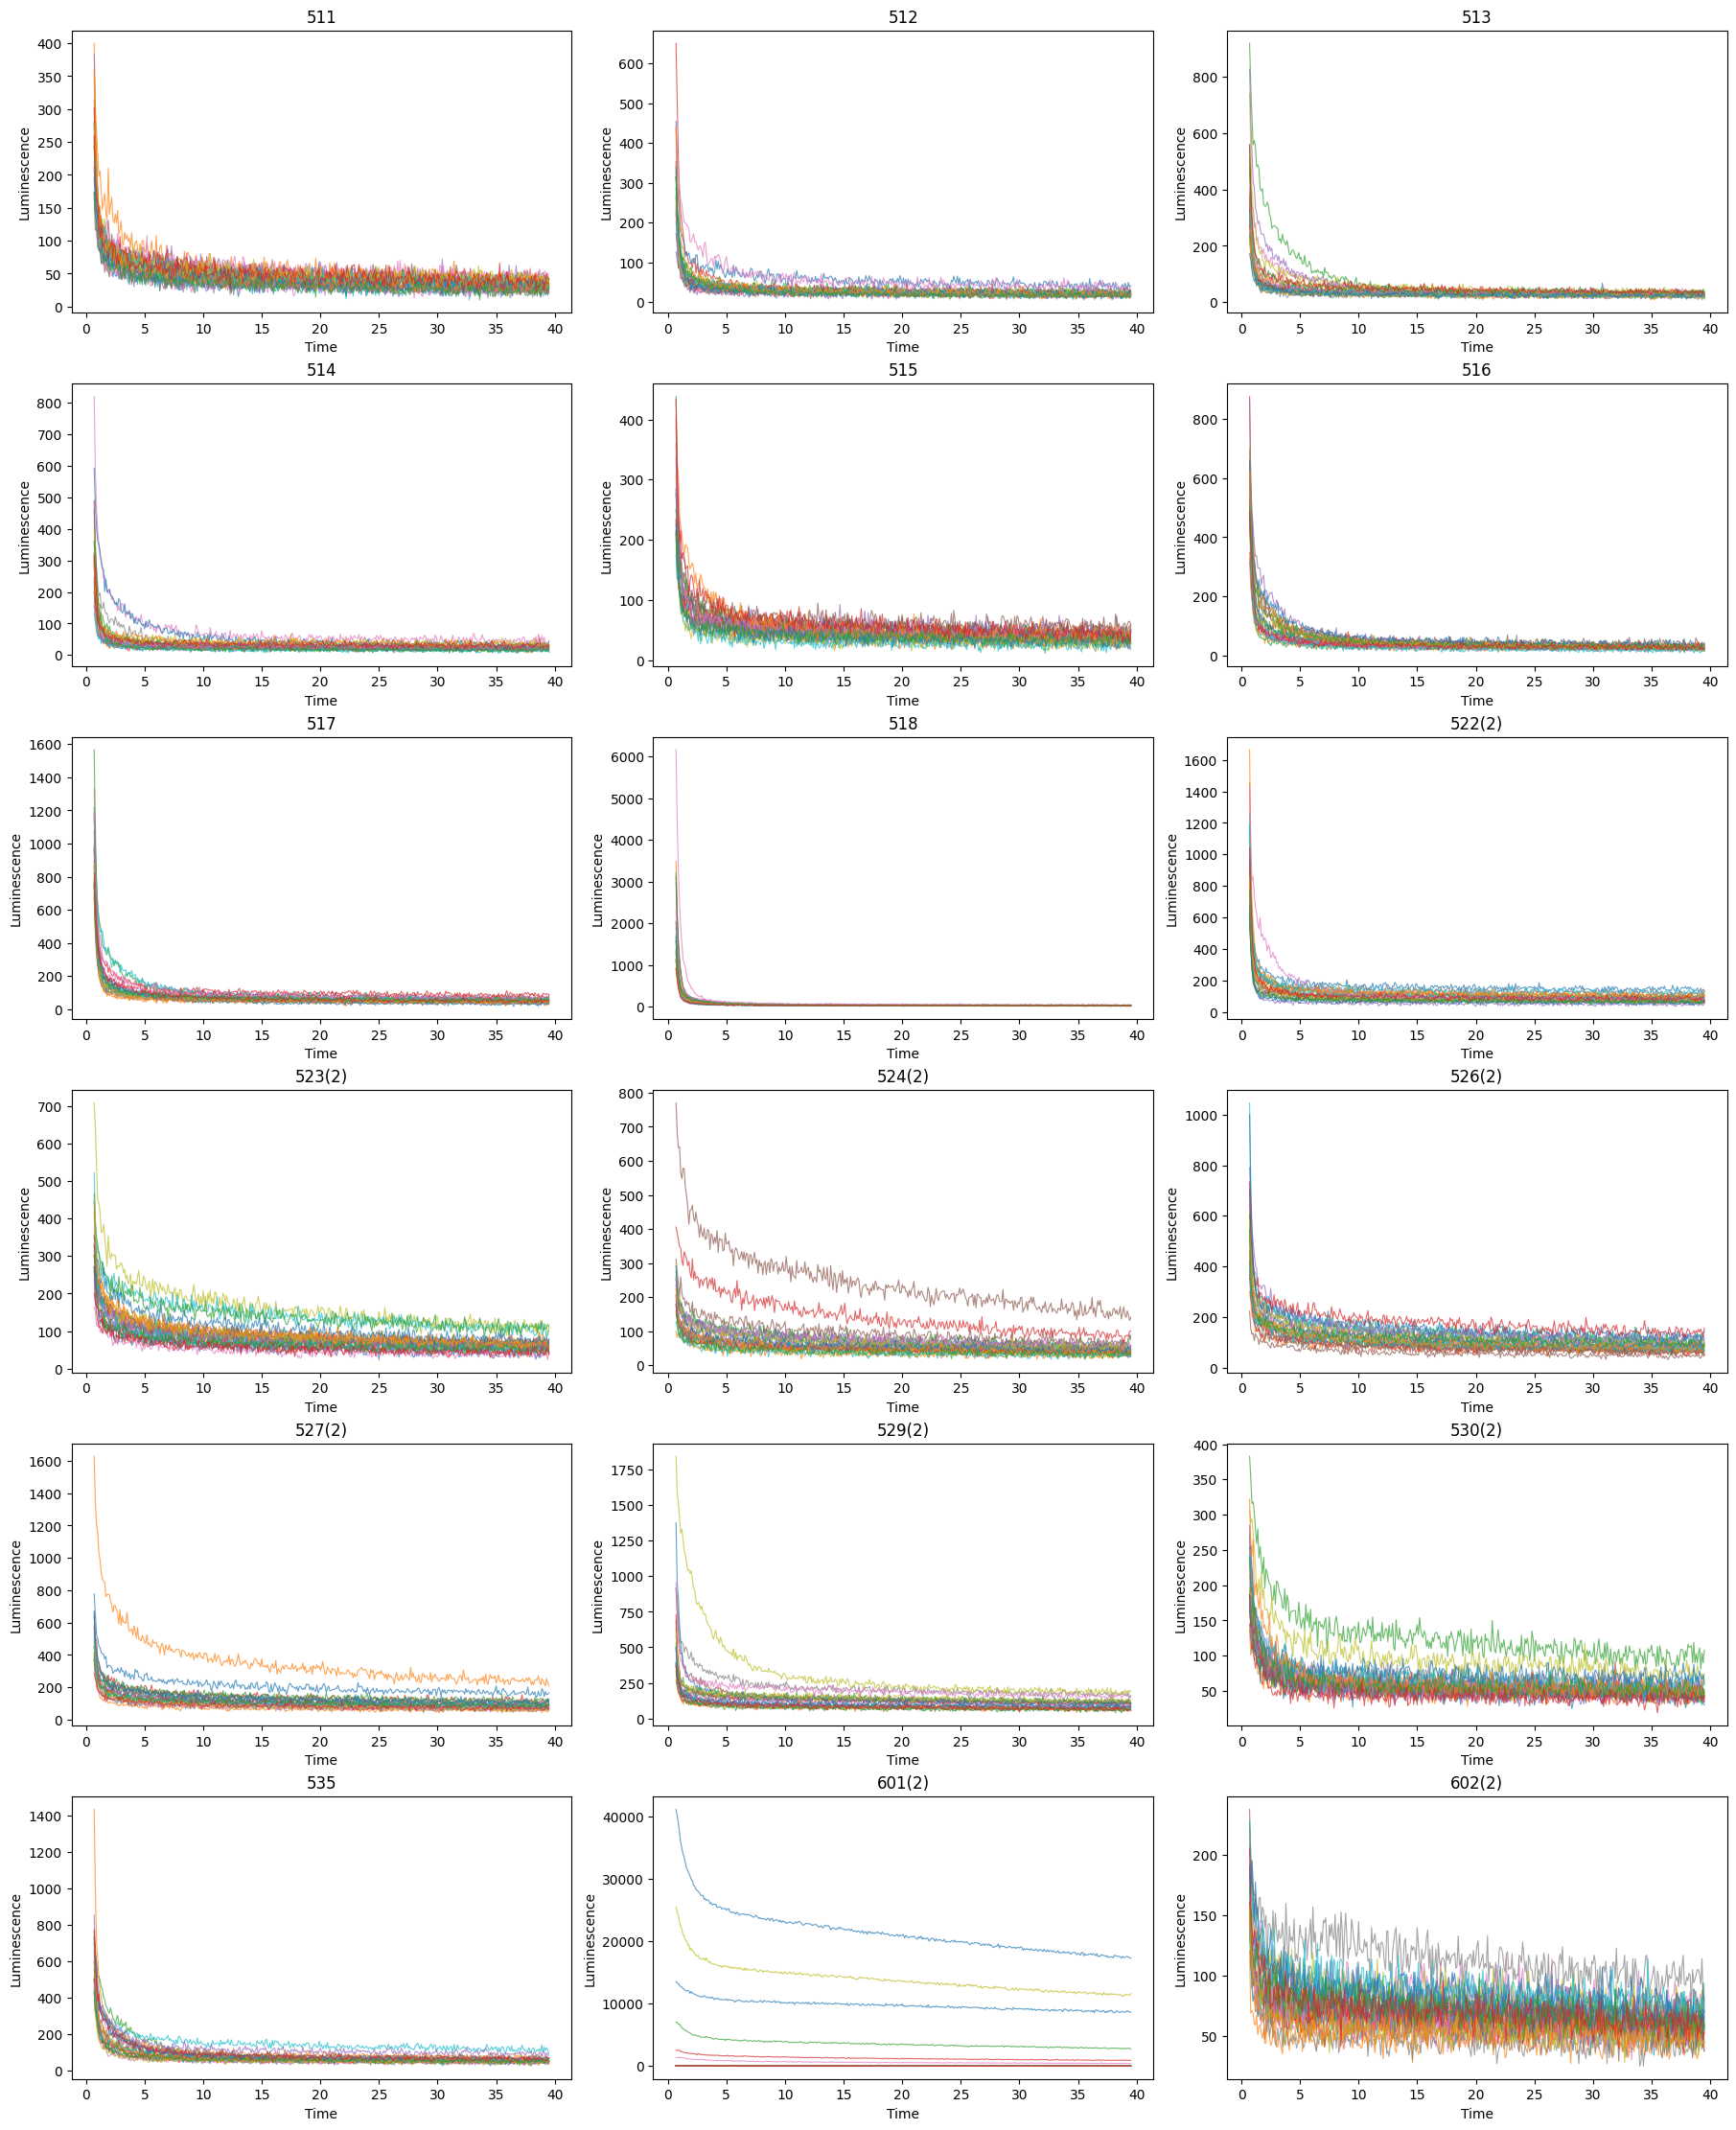

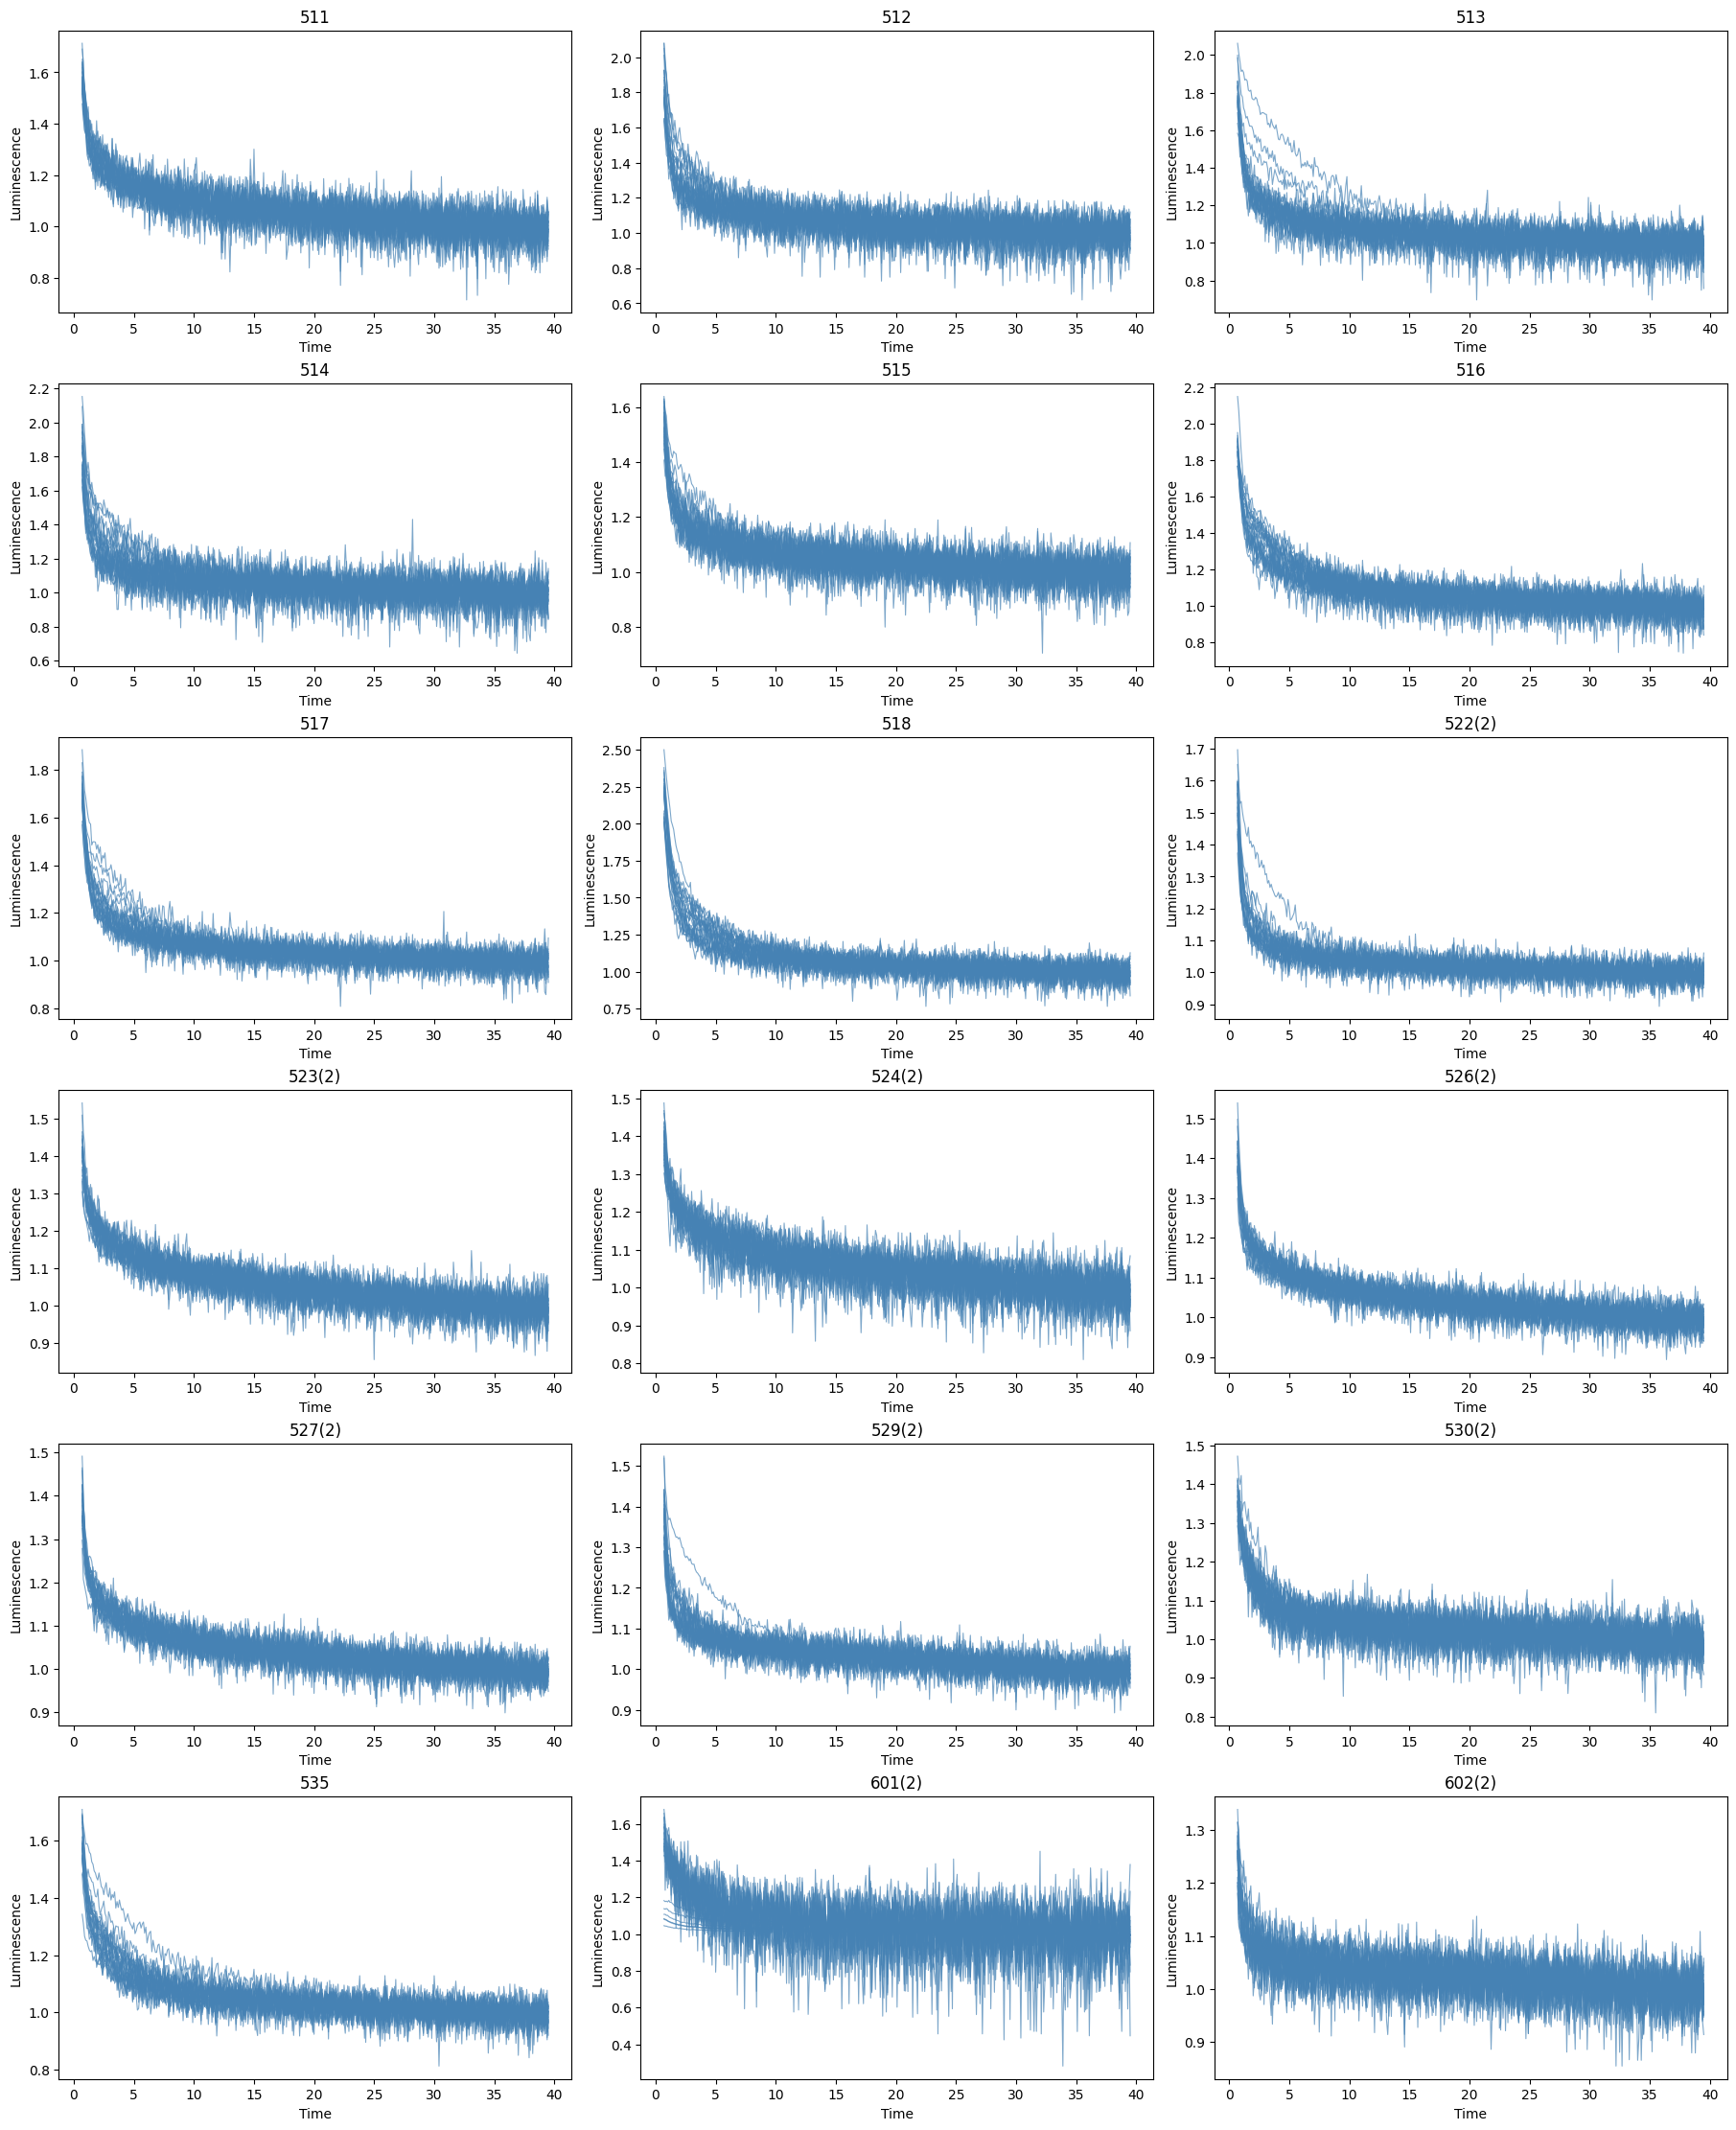

✓ raw & log-transformed data saved to output/Ocet10_merged_data_log.pkl


In [2]:
import os, pickle, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
excel_path  = 'data/New_data_20250715_M.xlsx'
output_dir  = 'output'
pickle_file = os.path.join(output_dir, 'Ocet10_merged_data_log.pkl')
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------
# 1.  Load sheets, clean, crop 7 ≤ Time_index ≤ 395
# ------------------------------------------------------------------
if not os.path.exists(excel_path):
    raise FileNotFoundError(f'{excel_path} not found!')

sheets   = pd.read_excel(excel_path, sheet_name=None, header=None)


raw_dict, log_dict = {}, {}



for name, df in sheets.items():
    # ─── 1. Skip blank worksheets ───
    if df.empty:
        print(f"Skipping empty sheet: {name}")
        continue

    # ─── 2. Safely drop the first two rows and transpose ───
    df_t = (
        df        # original
        .drop(index=df.index[:2])  # only drop if present
        .reset_index(drop=True)
        .T                                          # transpose
    )

    # … (rest of your loop is unchanged) 

    df_t.columns = df_t.iloc[0]   # promote first transposed row to header
    df_t = df_t.drop(index=0).reset_index(drop=True)
    # rename column 'datapoint' to 'Time_index' if it exists
    if 'datapoint' in df_t.columns:
        df_t = df_t.rename(columns={'datapoint': 'Time_index'})

    # df_t.columns = df_t.iloc[0]
    # df_t = df_t.drop(index=0).reset_index(drop=True)
    df_t = df_t.apply(pd.to_numeric)

    mask  = (df_t['Time_index'] >= 7) & (df_t['Time_index'] <= 395)
    df_t  = df_t.loc[mask].reset_index(drop=True)

    # ── log10 transform the slice columns only ───────────────────
    slice_cols = df_t.columns.difference(['Time_index', 'Time'])
    df_log = df_t.copy()
    df_log[slice_cols] = np.log10(df_log[slice_cols] + 1e-9)
    # df_log[slice_cols] = np.log(df_log[slice_cols] + 1e-9)   # base-e log

    # ── filter: keep slices whose entire log curve ≥ 0 ───────────
    good_cols = [
        c for c in slice_cols
        if (df_log[c] >= 0).all()
    ]
    n_dropped = len(slice_cols) - len(good_cols)
    if n_dropped:
        print(f'Sheet {name}: dropped {n_dropped} low-count slice(s)')

    # ── NORMALISE each good slice by mean of its last 100 values ─
    for col in good_cols:
        tail_mean = df_log[col].iloc[-100:].mean()  # fewer rows → uses all
        if tail_mean != 0:                          # guard against zero just in case
            df_log[col] /= tail_mean

    keep_cols = ['Time_index', 'Time'] + good_cols
    raw_dict[name] = df_t[keep_cols].copy()
    log_dict[name] = df_log[keep_cols].copy()

cleaned = raw_dict  # for quick-look plot later
# ------------------------------------------------------------------
# 2.  Quick-look plot : raw vs. log
# ------------------------------------------------------------------



fig, axes = plt.subplots(8, 3, figsize=(18, 28), layout='constrained')
axes = axes.ravel()

for ax, (name, df_t) in zip(axes, cleaned.items()):
    time    = df_t['Time'].astype(float).values
    slices  = df_t.drop(columns=['Time_index', 'Time'])

    ax.plot(time, slices.values, lw=0.8, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Time')
    ax.set_ylabel('Luminescence')

# remove unused panes if < 9 sheets
for ax in axes[len(cleaned):]:
    ax.remove()

plt.show()



fig, axes = plt.subplots(8, 3, figsize=(18, 28), layout='constrained')
axes = axes.ravel()

for ax, (name, df_t) in zip(axes, log_dict.items()):
    time    = df_t['Time'].astype(float).values
    slices  = df_t.drop(columns=['Time_index', 'Time'])

    ax.plot(time, slices.values, lw=0.8, alpha=0.7,color='steelblue')
    ax.set_title(name)
    ax.set_xlabel('Time')
    ax.set_ylabel('Luminescence')

# remove unused panes if < 9 sheets
for ax in axes[len(log_dict):]:
    ax.remove()

plt.show()



# ------------------------------------------------------------------
# 3.  Pickle both data sets
# ------------------------------------------------------------------
with open(pickle_file, 'wb') as f:
    pickle.dump(log_dict, f)

print(f'✓ raw & log-transformed data saved to {pickle_file}')

# save the raw data as well
raw_pickle_file = os.path.join(output_dir, 'Oct10_merged_data_ori.pkl')
with open(raw_pickle_file, 'wb') as f:
    pickle.dump(raw_dict, f)

# Finding linear mixing ratio

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


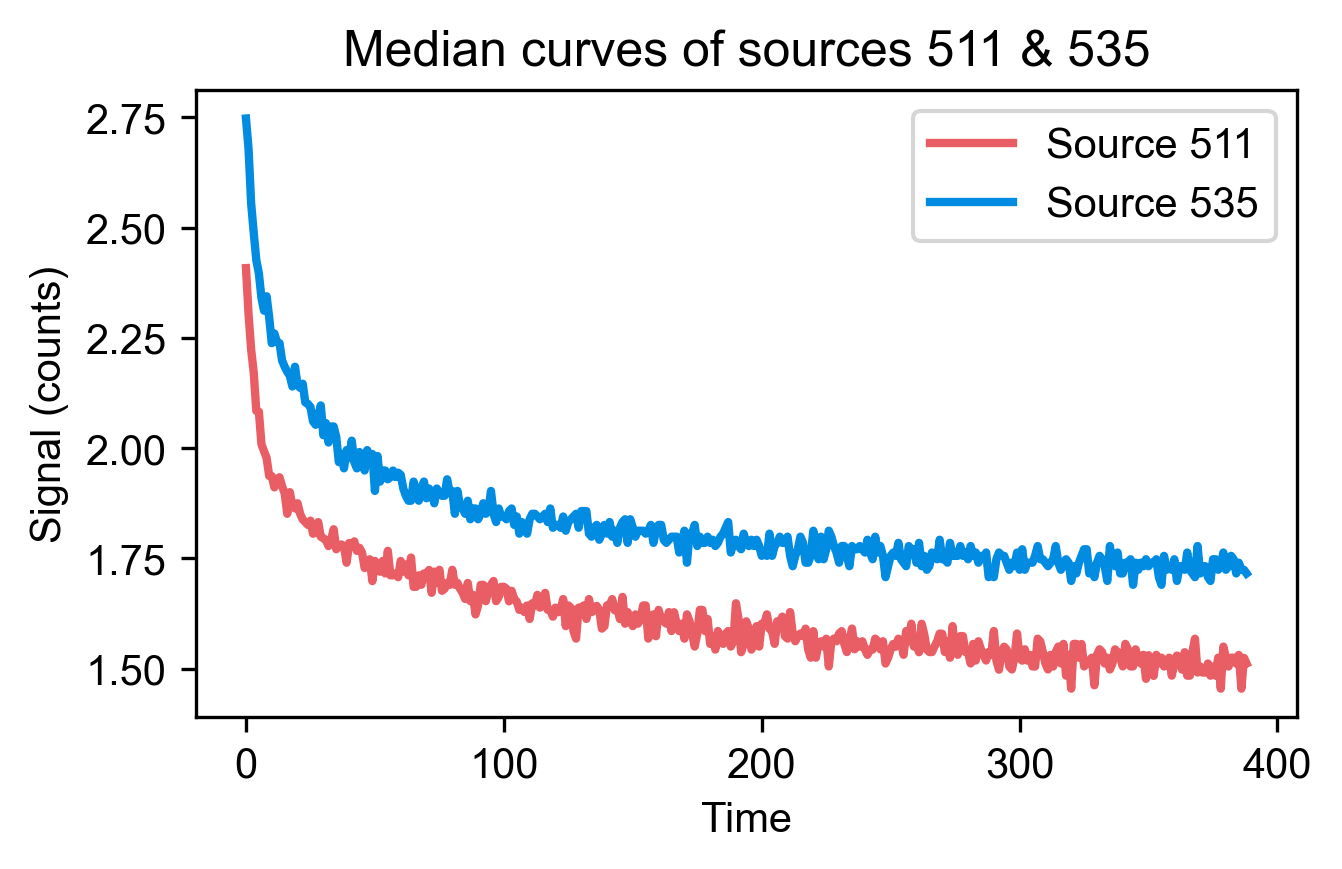

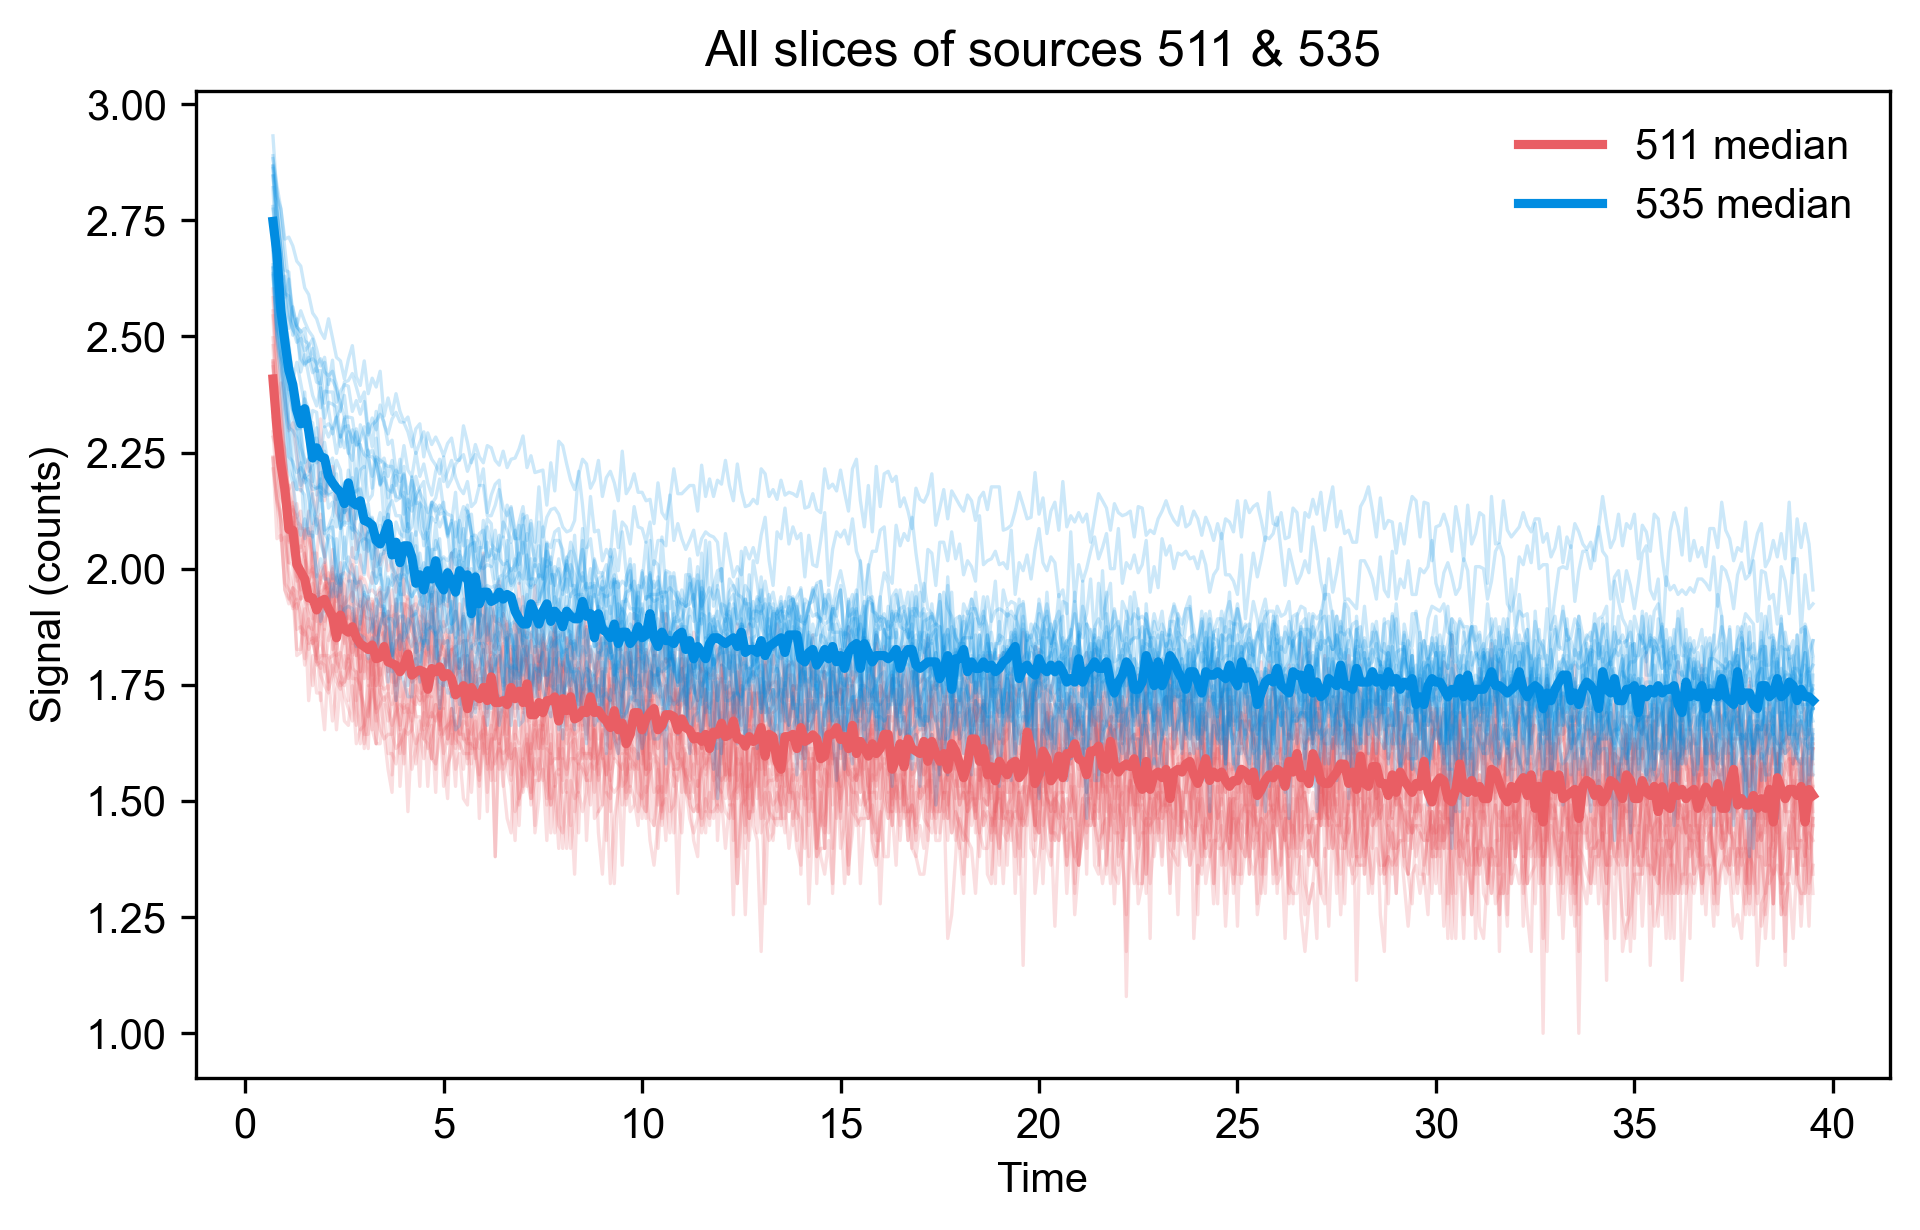

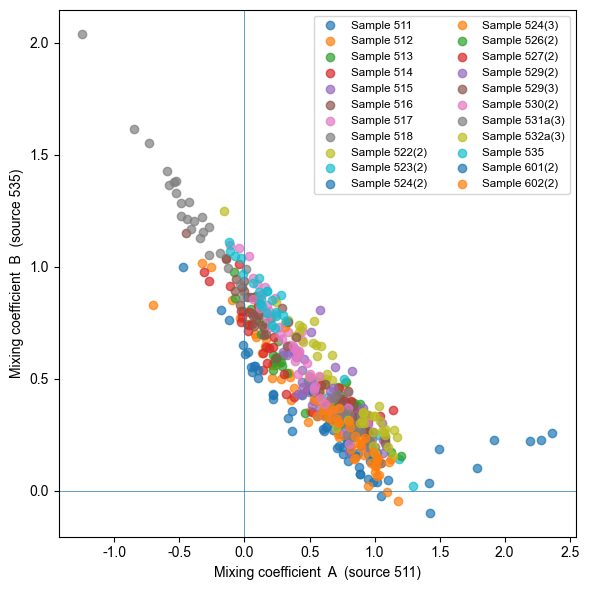

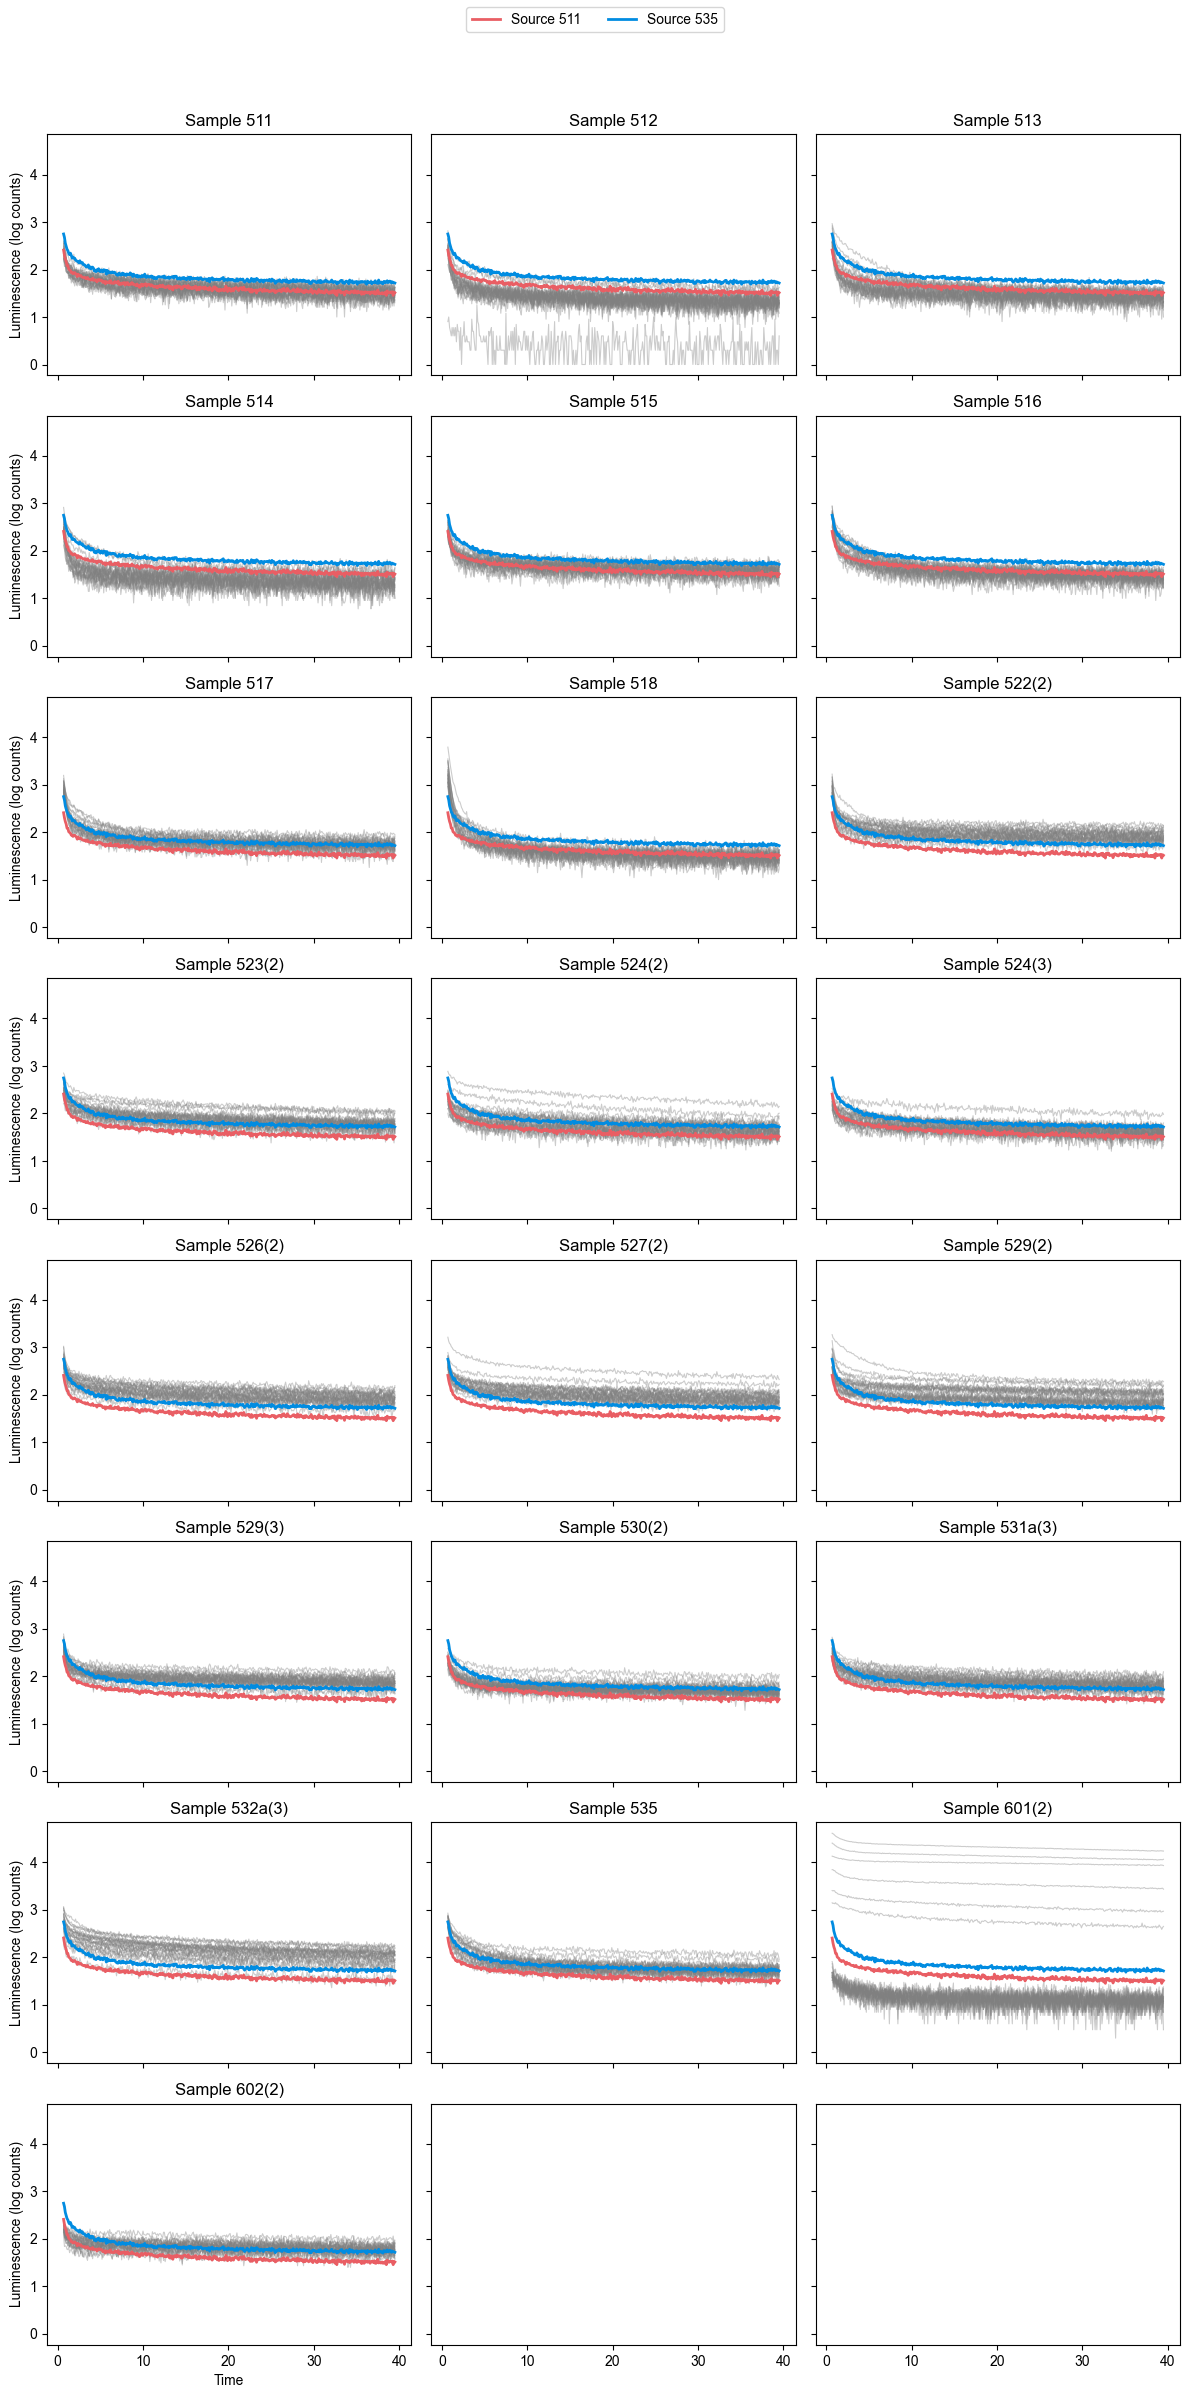

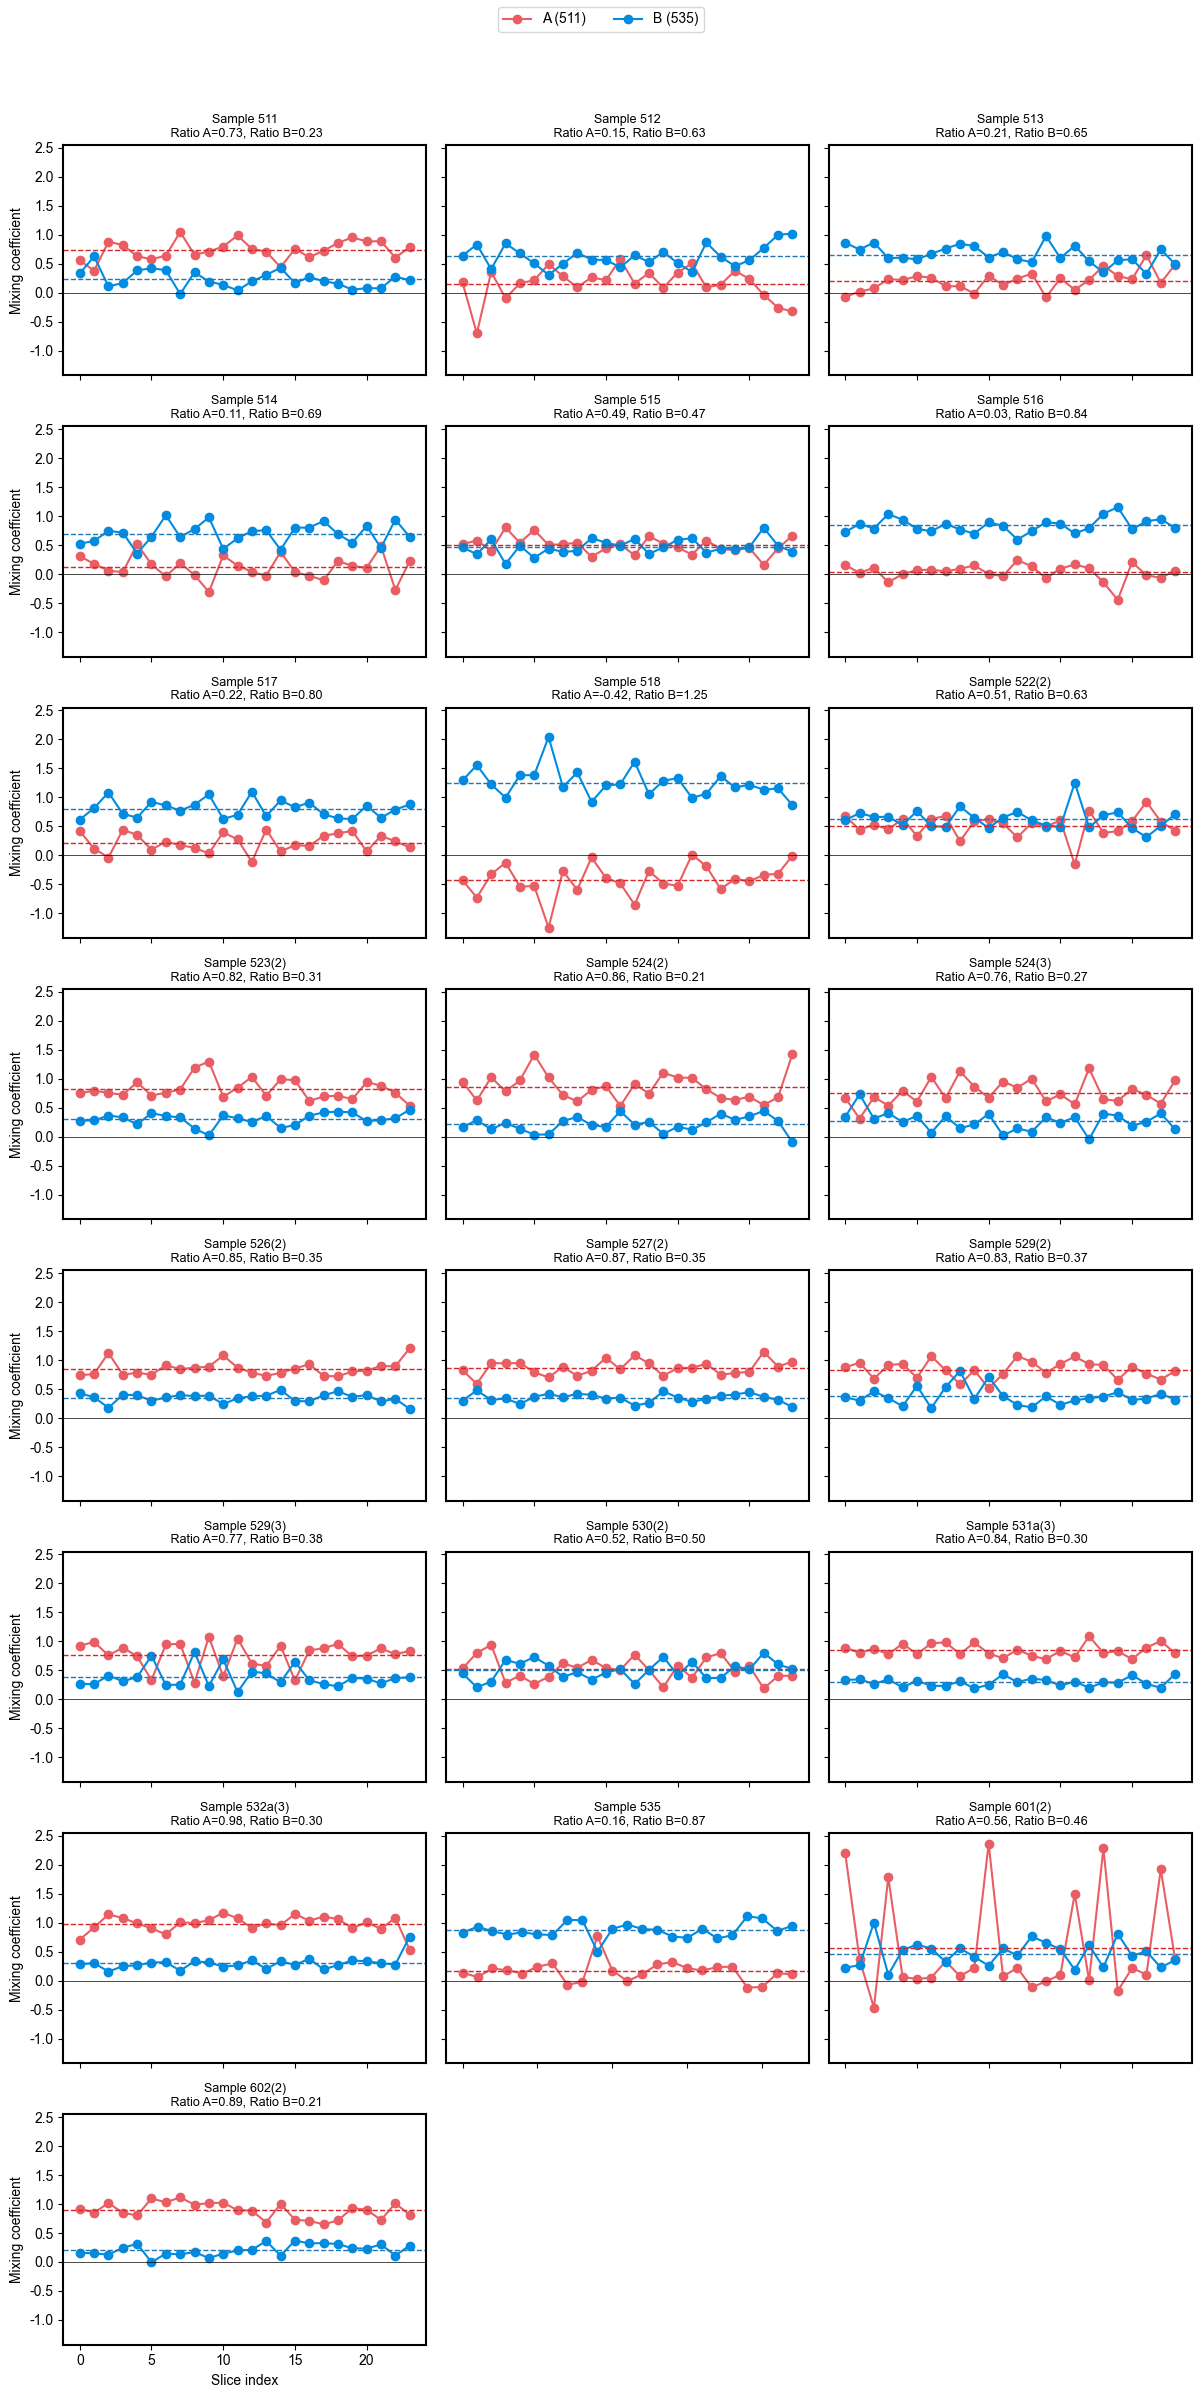

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [4]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],  # will fall back if Arial not found
    "axes.unicode_minus": False,   # keep minus signs as proper unicode
    "pdf.fonttype": 42,            # TrueType in PDFs (editable in Adobe/Illustrator)
    "ps.fonttype": 42,             # TrueType in EPS
    "svg.fonttype": "none",        # keep text as text in SVGs (if you use SVG)
})





# ─────────────────────────────────────────────────────────────
# 0.  CHOOSE THE TWO SOURCE SAMPLES HERE
# ─────────────────────────────────────────────────────────────
SOURCE_A = "511"      # e.g. "511", "601(2)", "535" …
SOURCE_B = "535"      # any other sample key in the pickle

# ─────────────────────────────────────────────────────────────
# 1.  Imports & data load
# ─────────────────────────────────────────────────────────────
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA     # (still here if you need it)

PICKLE = "output/Oct10_Merged_data_log.pkl"
if not os.path.exists(PICKLE):
    raise FileNotFoundError(f"Pickle not found: {PICKLE}")

with open(PICKLE, "rb") as f:
    data_dict = pickle.load(f)

# ─────────────────────────────────────────────────────────────
# 2.  Helper utilities
# ─────────────────────────────────────────────────────────────
def sample_matrix(sample_key):
    """Return (time, X, slice_names).
       X  shape → (n_slices, n_time)  (each row = one slice)."""
    df = data_dict[sample_key]
    time = df["Time"].astype(float).values
    slice_cols = df.columns.difference(["Time_index", "Time"])
    X = df[slice_cols].to_numpy(dtype=float).T   # rows = slices
    return time, X, slice_cols

def median_curve(sample_key):
    """Median (across slices) OSL curve for one sample."""
    df = data_dict[sample_key]
    slice_cols = df.columns.difference(["Time_index", "Time"])
    return df[slice_cols].median(axis=1).values   # 1‑D (n_time,)



bad_cols = ["Sample_535(2)"]
if "535" in data_dict:
    data_dict["535"].drop(columns=bad_cols, errors="ignore", inplace=True)



# ─────────────────────────────────────────────────────────────
# 3.  Build the 2‑column *design matrix* from the two sources
# ─────────────────────────────────────────────────────────────
sourceA = median_curve(SOURCE_A)
sourceB = median_curve(SOURCE_B)

# stack as    S  shape = (n_time, 2)
S     = np.vstack([sourceA, sourceB]).T
pinvS = np.linalg.pinv(S)          # pre‑computed pseudo‑inverse

# (optional) nice colours
cmap  = plt.colormaps["tab10"]
# colA, colB = cmap(0), cmap(8)
# set colA to rgba(233, 94, 100)
# set colB to rgba(1, 140, 225)
colA = (233/255, 94/255, 100/255)
colB = (1/255, 140/255, 225/255)






# ------------------ quick visual check of the two sources ---
plt.figure(figsize=(4.5,3), dpi=300)
plt.plot(sourceA, lw=2, color=colA, label=f"Source {SOURCE_A}")
plt.plot(sourceB, lw=2, color=colB, label=f"Source {SOURCE_B}")
plt.xlabel("Time"); plt.ylabel("Signal (counts)")
plt.title(f"Median curves of sources {SOURCE_A} & {SOURCE_B}")
plt.legend(); plt.tight_layout()
plt.savefig(f"Figures/source_curves_{SOURCE_A}_{SOURCE_B}.png", dpi=600)
plt.savefig(f"Figures/source_curves_{SOURCE_A}_{SOURCE_B}.pdf", dpi=600)
# save figure to eps vector format too
plt.savefig(f"Figures/source_curves_{SOURCE_A}_{SOURCE_B}.eps", dpi=600)
plt.show()





# ─────────────────────────────────────────────────────────────
# 3b. NEW: one figure with ALL slices from sources 511 & 535
# ─────────────────────────────────────────────────────────────
# Grab all slices for each source
timeA, XA, _ = sample_matrix(SOURCE_A)   # XA shape: (n_slices_A, n_time_A)
timeB, XB, _ = sample_matrix(SOURCE_B)   # XB shape: (n_slices_B, n_time_B)

# Make sure the output folder exists
os.makedirs("Figures", exist_ok=True)

plt.figure(figsize=(6.5, 4.2), dpi=300)

# Plot every slice for SOURCE_A in the specified rgb(233, 94, 100)
for row in XA:
    plt.plot(timeA, row, color=colA, alpha=0.2, lw=0.8)

# Plot every slice for SOURCE_B in the specified rgb(1, 140, 225)
for row in XB:
    plt.plot(timeB, row, color=colB, alpha=0.2, lw=0.8)

# Emphasize the medians for each source on top
plt.plot(timeA, np.nanmedian(XA, axis=0), color=colA, lw=2.2,
         label=f"{SOURCE_A} median")
plt.plot(timeB, np.nanmedian(XB, axis=0), color=colB, lw=2.2,
         label=f"{SOURCE_B} median")

plt.xlabel("Time")
plt.ylabel("Signal (counts)")
plt.title(f"All slices of sources {SOURCE_A} & {SOURCE_B}")
plt.legend(frameon=False)
plt.tight_layout()

# # Save as PNG/PDF/EPS
# plt.savefig(f"Figures/all_slices_sources_{SOURCE_A}_{SOURCE_B}.png", dpi=600)
# plt.savefig(f"Figures/all_slices_sources_{SOURCE_A}_{SOURCE_B}.pdf", dpi=600)
# plt.savefig(f"Figures/all_slices_sources_{SOURCE_A}_{SOURCE_B}.eps", dpi=600)
plt.show()




# ─────────────────────────────────────────────────────────────
# 4.  Solve mixing coefficients (A, B) for EVERY SLICE
# ─────────────────────────────────────────────────────────────
results = []   # will become a DataFrame

for sample_key in sorted(data_dict):
    time, Xs, slice_cols = sample_matrix(sample_key)   # Xs rows = slices
    for row, slice_name in zip(Xs, slice_cols):
        A, B = pinvS @ row          # linear‑regression coefficients
        results.append({"sample": sample_key,
                        "slice":  slice_name,
                        f"A({SOURCE_A})": A,
                        f"B({SOURCE_B})": B})

results_df = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────
# 5.  Scatter‑plot (A vs. B)   — one colour per sample
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(6,6))
for sample_key, grp in results_df.groupby("sample"):
    plt.scatter(grp[f"A({SOURCE_A})"], grp[f"B({SOURCE_B})"],
                label=f"Sample {sample_key}", alpha=0.7)
plt.axhline(0, lw=0.5); plt.axvline(0, lw=0.5)
plt.xlabel(f"Mixing coefficient  A  (source {SOURCE_A})")
plt.ylabel(f"Mixing coefficient  B  (source {SOURCE_B})")
plt.legend(fontsize="small", ncol=2)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# 6.  Overlay of all slices + the two source curves
#     (6 × 3 subplot grid, auto‑adjust rows)
# ─────────────────────────────────────────────────────────────
samples   = sorted(data_dict)
ncols     = 3
nrows     = int(np.ceil(len(samples)/ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axes = axes.ravel()

for ax, sample_key in zip(axes, samples):
    time, Xs, _ = sample_matrix(sample_key)
    ax.plot(time, Xs.T, color="grey", alpha=0.4, lw=0.8)   # all slices
    ax.plot(time, sourceA, lw=2, color=colA, label=f"Source {SOURCE_A}")
    ax.plot(time, sourceB, lw=2, color=colB, label=f"Source {SOURCE_B}")
    ax.set_title(f"Sample {sample_key}")
    if sample_key == samples[-1]:              # label only bottom row
        ax.set_xlabel("Time")
    if sample_key == samples[0] or (axes.tolist().index(ax) % ncols == 0):
        ax.set_ylabel("Luminescence (log counts)")

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.tight_layout(rect=[0,0,1,0.96])
plt.show()

# ─────────────────────────────────────────────────────────────
# 7.  Per‑slice A & B line‑plots for every sample
# ─────────────────────────────────────────────────────────────
def plot_AB_across_slices(df, n_cols=3):
    samples   = sorted(df["sample"].unique())
    n_rows    = int(np.ceil(len(samples)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols, 3*n_rows),
                             sharey=True, dpi=100)
    axes_flat = axes.ravel()

    for idx, (ax, smp) in enumerate(zip(axes_flat, samples)):
        grp = df.loc[df["sample"] == smp].reset_index(drop=True)
        x   = np.arange(len(grp))
        ax.plot(x, grp[f"A({SOURCE_A})"], "-o", lw=1.5, color=colA,
                label=f"A ({SOURCE_A})")
        ax.plot(x, grp[f"B({SOURCE_B})"], "-o", lw=1.5, color=colB,
                label=f"B ({SOURCE_B})")
        meanA, meanB = grp[f"A({SOURCE_A})"].mean(), grp[f"B({SOURCE_B})"].mean()
        ax.axhline(meanA, ls="--", lw=1, color="tab:red")
        ax.axhline(meanB, ls="--", lw=1, color="tab:blue")
        ax.axhline(0, color="k", lw=0.5)
        if idx >= (n_rows-1)*n_cols: ax.set_xlabel("Slice index")
        else:                        ax.set_xticklabels([])
        if idx % n_cols == 0:        ax.set_ylabel("Mixing coefficient")
        # ax.set_title(f"Sample {smp}\n A={meanA:.2f}, B={meanB:.2f}",
        #              fontsize=9)
        ax.set_title(f"Sample {smp}\n Ratio A={meanA:.2f}, Ratio B={meanB:.2f}",
                     fontsize=9)
        for sp in ax.spines.values(): sp.set_linewidth(1.5)

    for ax in axes_flat[len(samples):]:
        ax.set_visible(False)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.tight_layout(rect=[0,0,1,0.96])

    plt.show()

    fig.savefig(f"Figures/AandB_{SOURCE_A}_{SOURCE_B}.png",
                dpi=600, bbox_inches="tight")
    fig.savefig(f"Figures/AandB_{SOURCE_A}_{SOURCE_B}.pdf",
                dpi=600, bbox_inches="tight")
    fig.savefig(f"Figures/AandB_{SOURCE_A}_{SOURCE_B}.eps",
                dpi=600, bbox_inches="tight")

plot_AB_across_slices(results_df)


# Finding mixing ratio, with removing bad slices

Sample 511: 24 slices
Sample 512: 24 slices
Sample 513: 24 slices
Sample 514: 24 slices
Sample 515: 24 slices
Sample 516: 24 slices
Sample 517: 24 slices
Sample 518: 24 slices
Sample 522(2): 24 slices
Sample 523(2): 24 slices
Sample 524(2): 24 slices
Sample 524(3): 24 slices
Sample 526(2): 24 slices
Sample 527(2): 24 slices
Sample 529(2): 24 slices
Sample 529(3): 24 slices
Sample 530(2): 24 slices
Sample 531a(3): 24 slices
Sample 532a(3): 24 slices
Sample 535: 24 slices
Sample 601(2): 24 slices
Sample 602(2): 24 slices
Sample 511: 24 slices
Sample 512: 19 slices
Sample 513: 24 slices
Sample 514: 23 slices
Sample 515: 24 slices
Sample 516: 24 slices
Sample 517: 24 slices
Sample 518: 24 slices
Sample 522(2): 24 slices
Sample 523(2): 24 slices
Sample 524(2): 24 slices
Sample 524(3): 24 slices
Sample 526(2): 24 slices
Sample 527(2): 24 slices
Sample 529(2): 24 slices
Sample 529(3): 24 slices
Sample 530(2): 24 slices
Sample 531a(3): 24 slices
Sample 532a(3): 24 slices
Sample 535: 24 slices


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


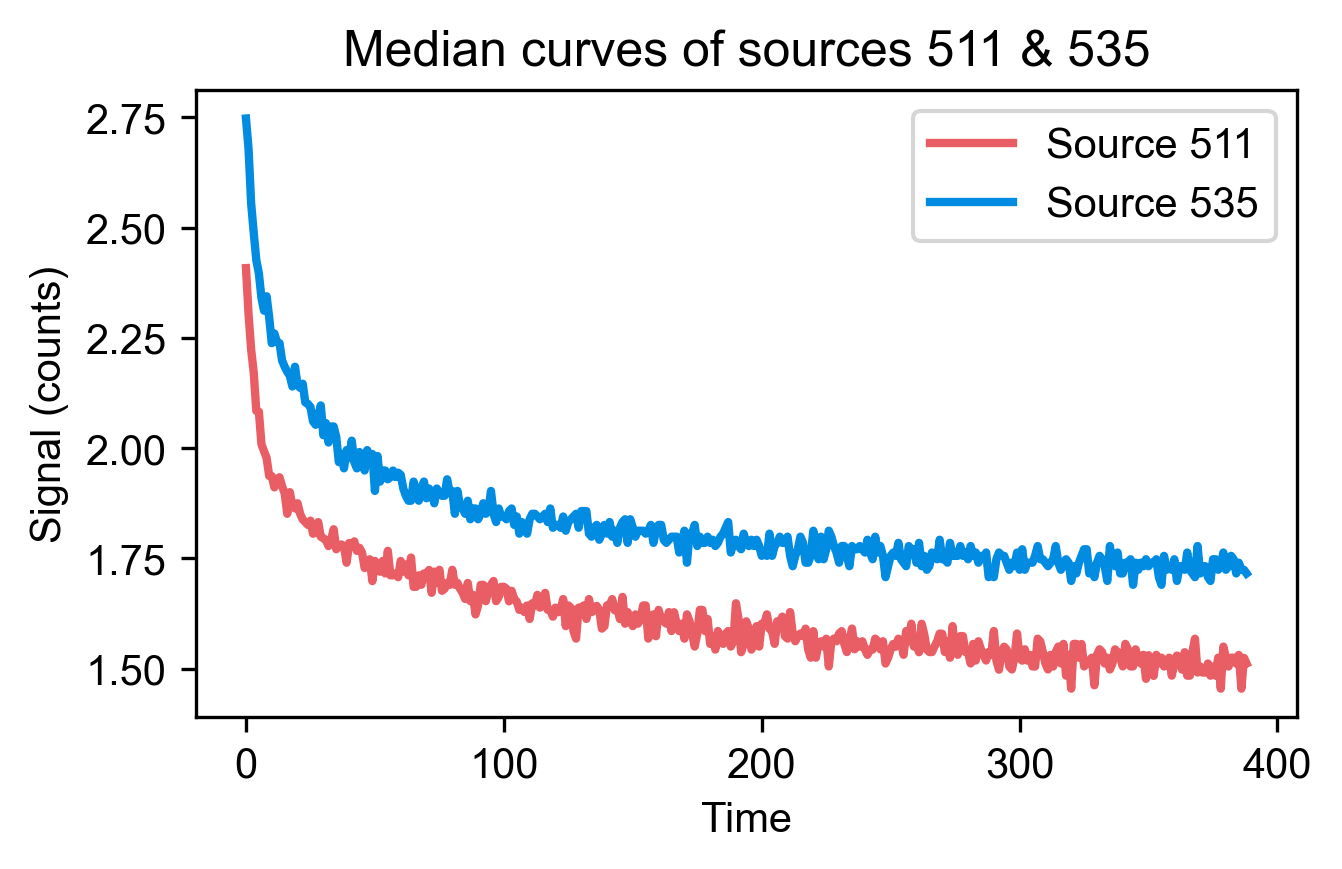

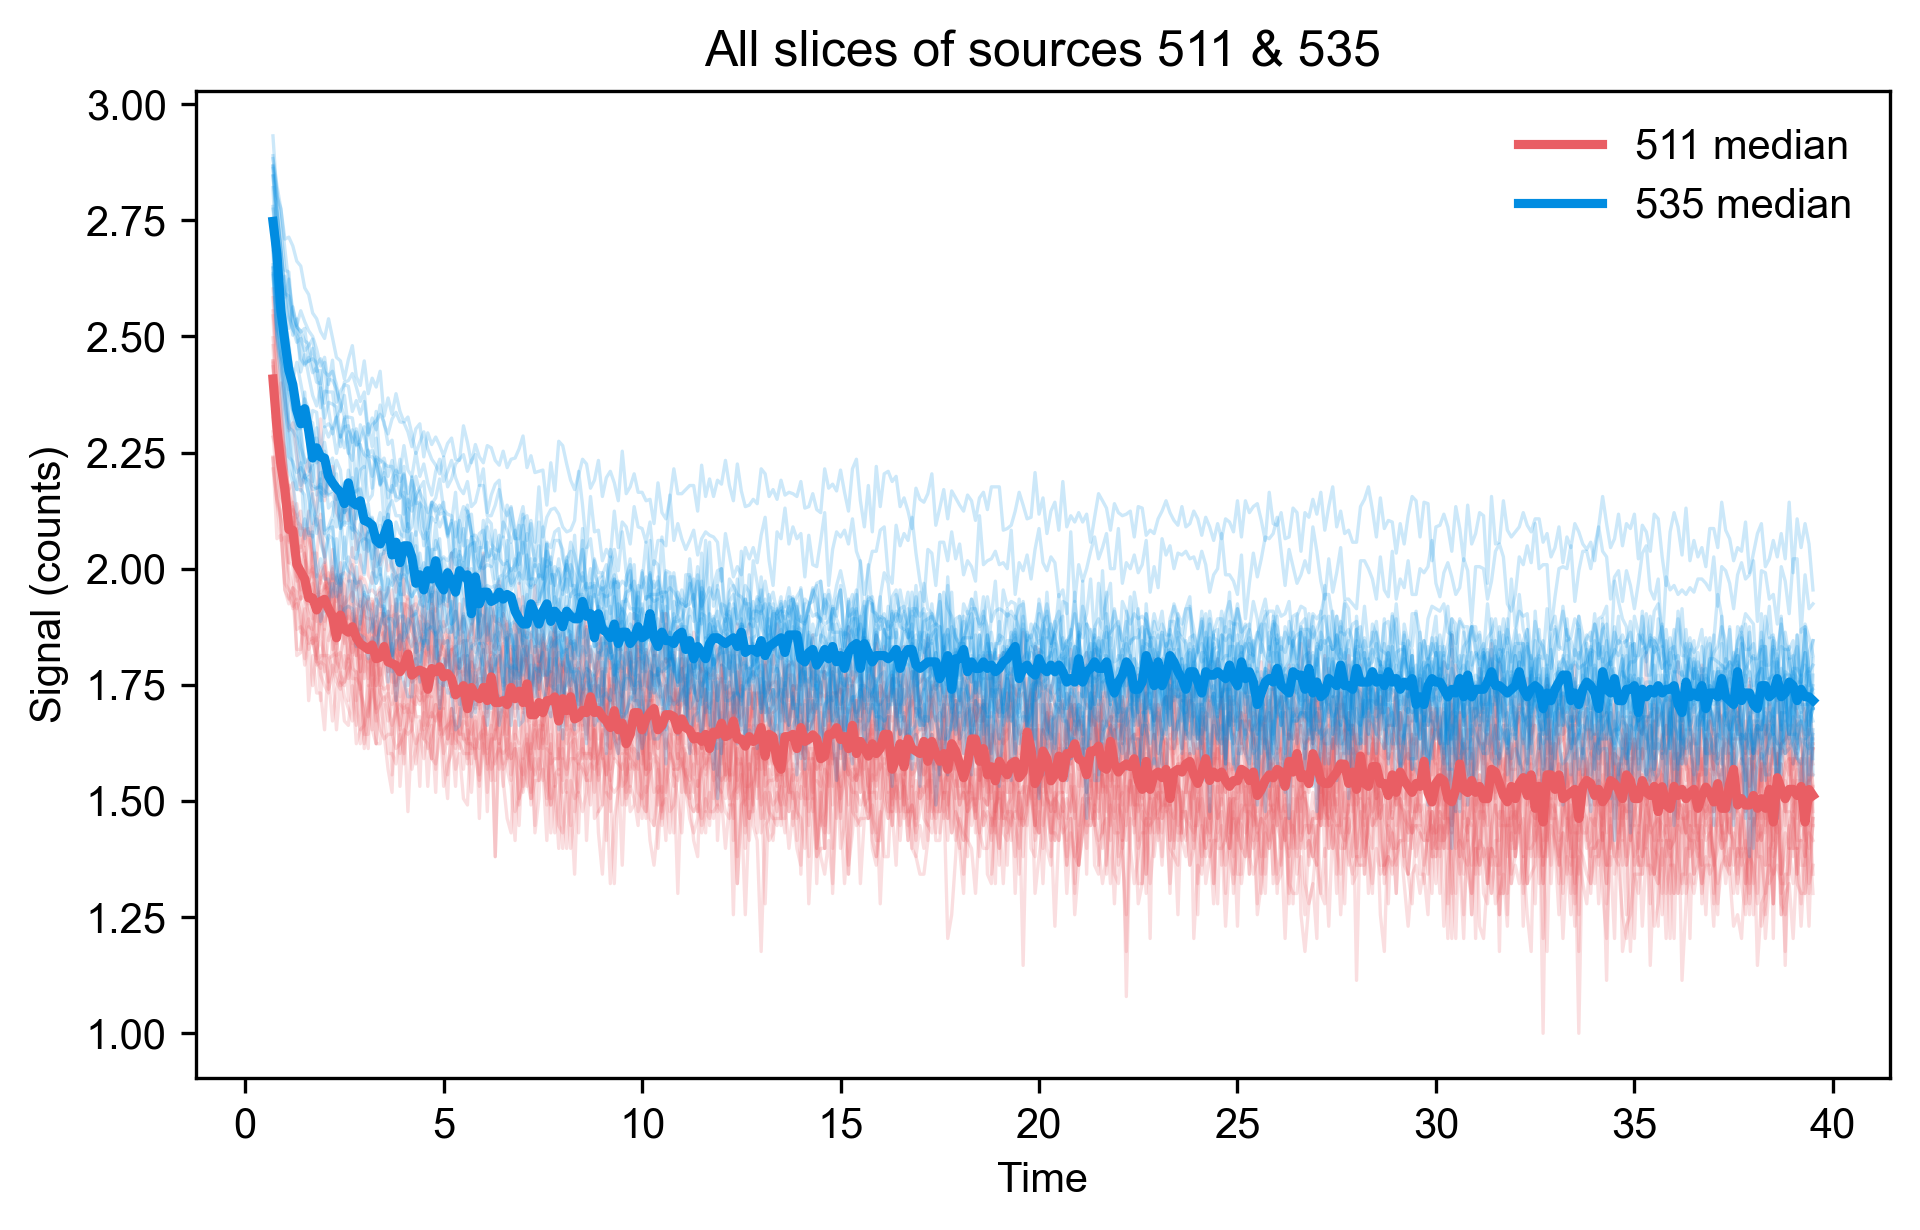

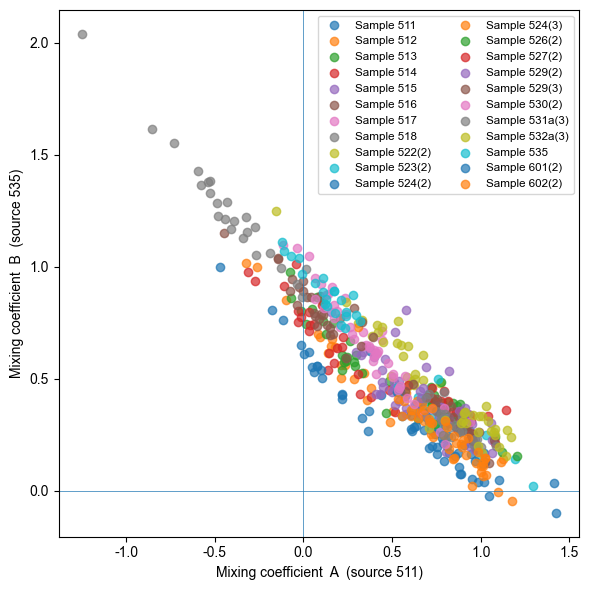

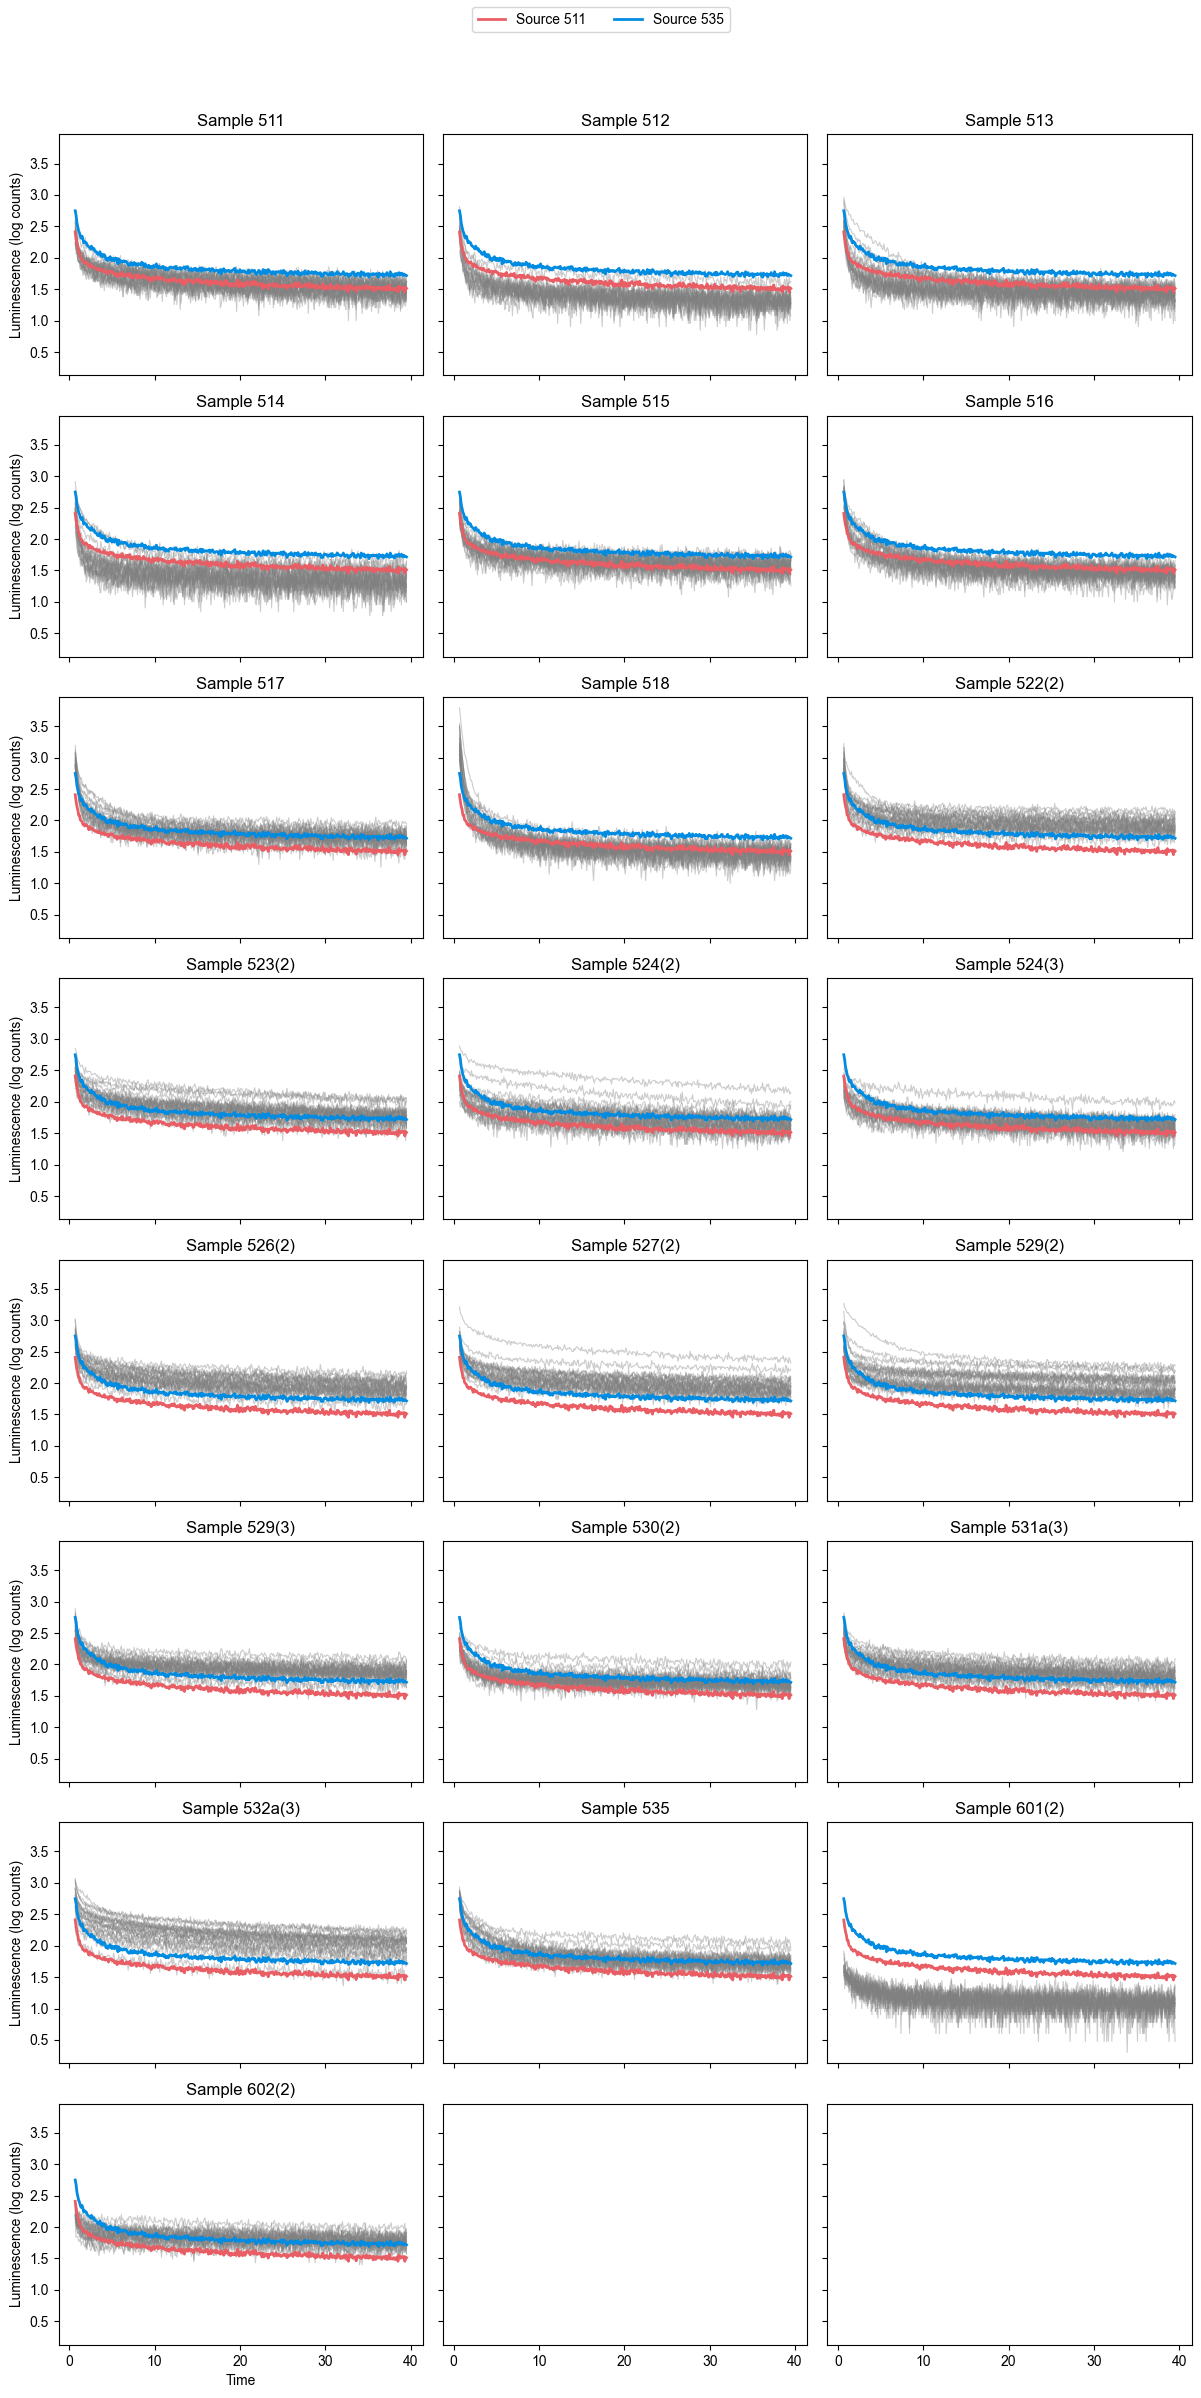

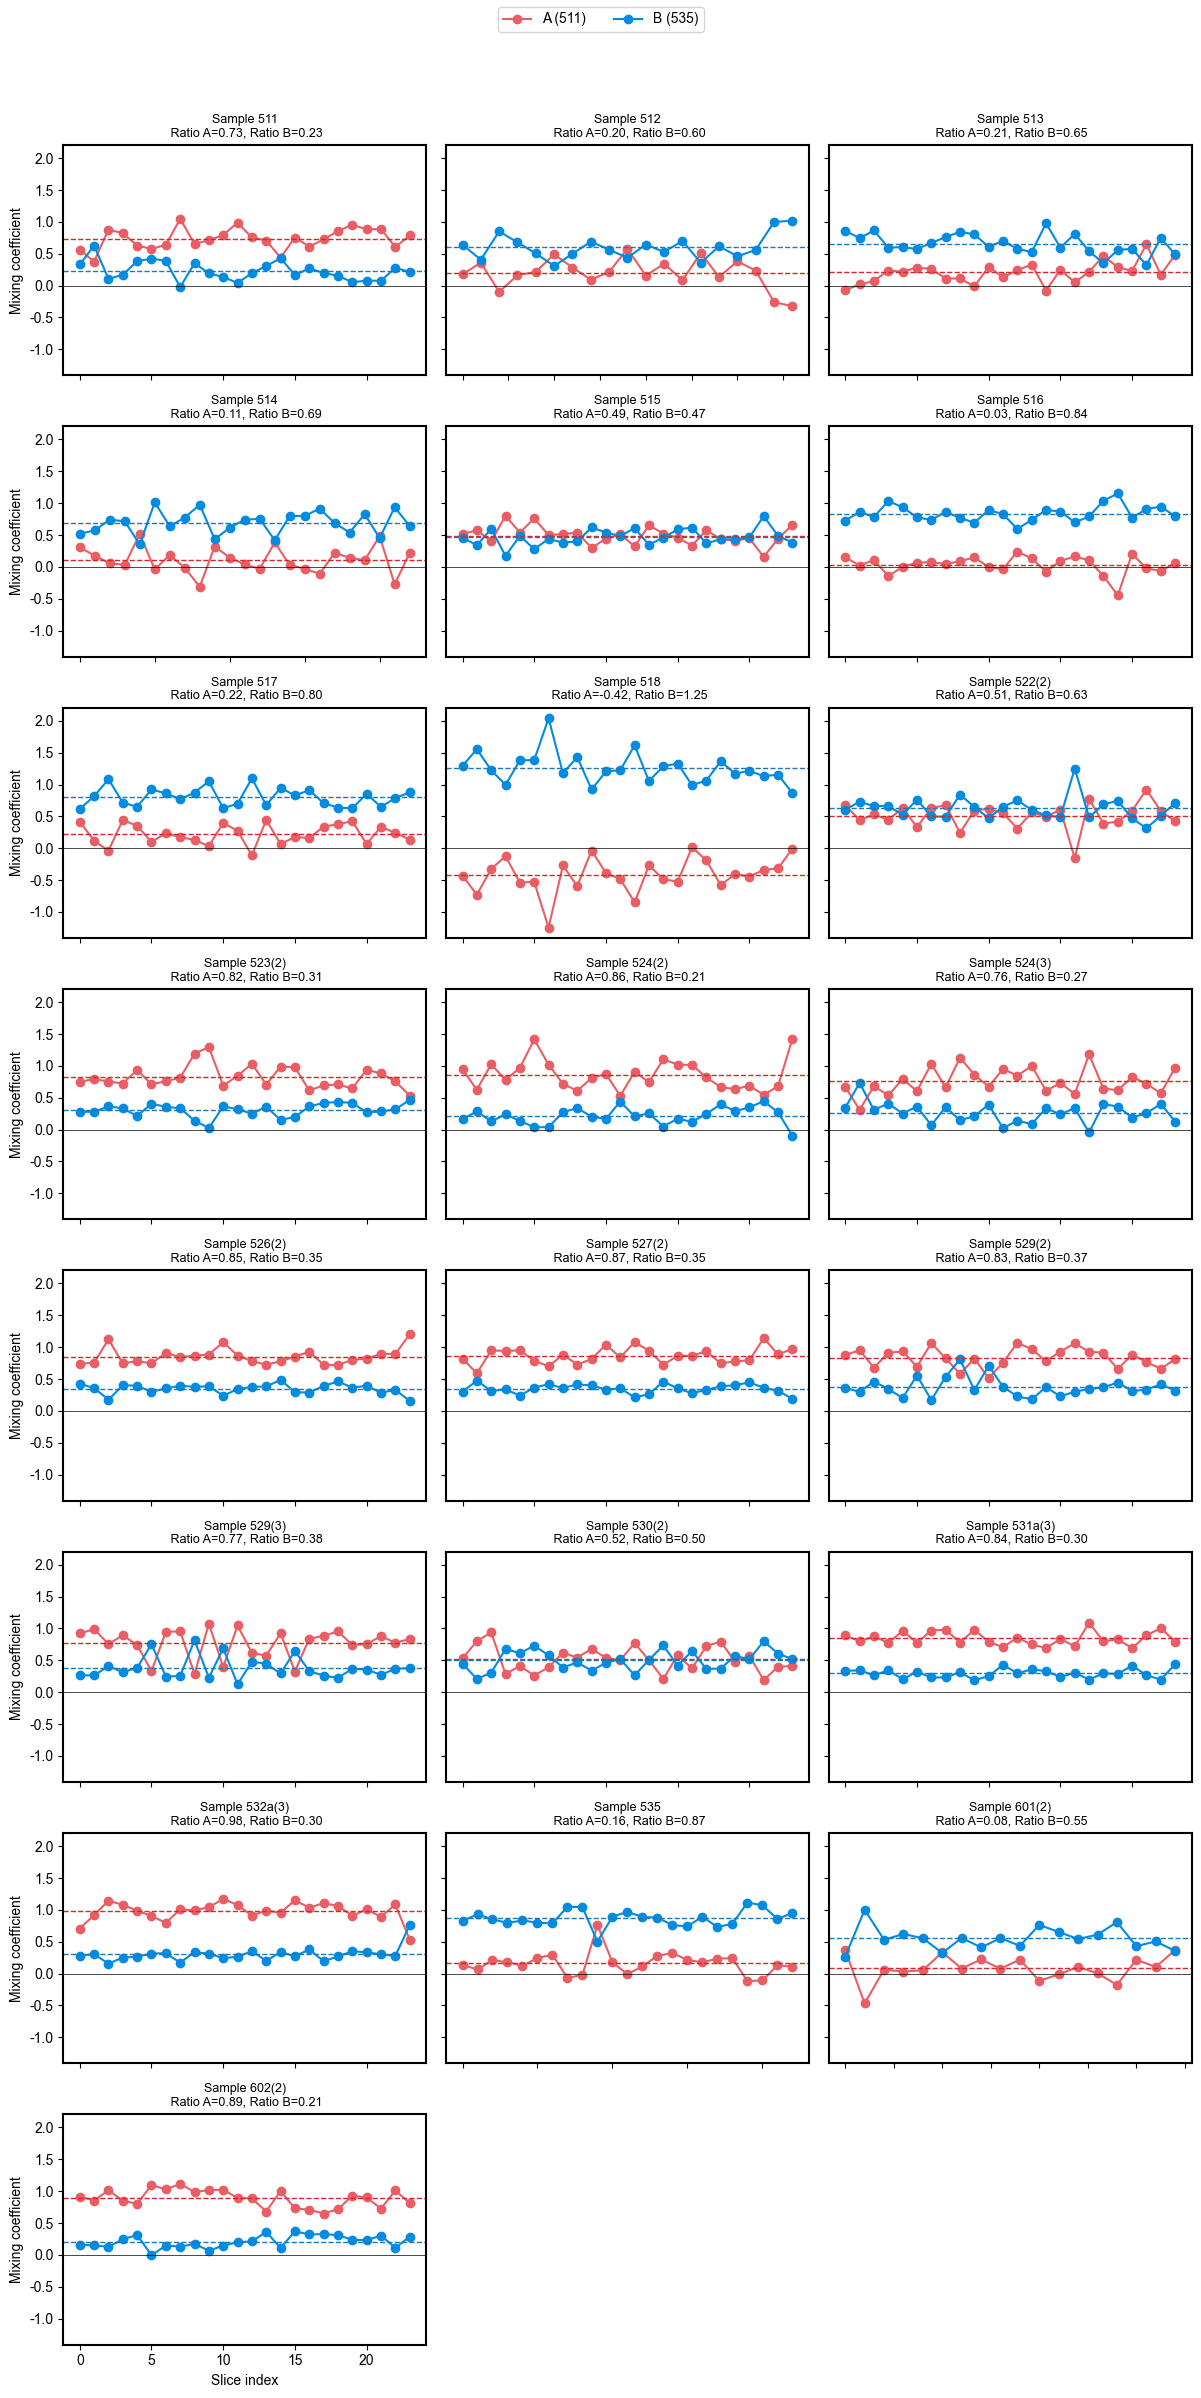

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [3]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],  # will fall back if Arial not found
    "axes.unicode_minus": False,   # keep minus signs as proper unicode
    "pdf.fonttype": 42,            # TrueType in PDFs (editable in Adobe/Illustrator)
    "ps.fonttype": 42,             # TrueType in EPS
    "svg.fonttype": "none",        # keep text as text in SVGs (if you use SVG)
})



# ─────────────────────────────────────────────────────────────
# 0.  CHOOSE THE TWO SOURCE SAMPLES HERE
# ─────────────────────────────────────────────────────────────
SOURCE_A = "511"      # e.g. "511", "601(2)", "535" …
SOURCE_B = "535"      # any other sample key in the pickle

# ─────────────────────────────────────────────────────────────
# 1.  Imports & data load
# ─────────────────────────────────────────────────────────────
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA     # (still here if you need it)

PICKLE = "output/Oct10_Merged_data_log.pkl"
if not os.path.exists(PICKLE):
    raise FileNotFoundError(f"Pickle not found: {PICKLE}")

with open(PICKLE, "rb") as f:
    data_dict = pickle.load(f)




########### Drop known bad slices here ###########
# print slice count in each sample before dropping
for sample_key in data_dict:
    print(f"Sample {sample_key}: {data_dict[sample_key].shape[1]-2} slices")

bad_cols = ["Sample_512(3)","Sample_512(7)","Sample_512(10)","Sample_512(18)", "Sample_512(23)",
            "Sample_514(14)",
            
            "Sample_601(1)","Sample_601(4)","Sample_601(8)",
            "Sample_601(12)","Sample_601(19)","Sample_601(24)"]
# if "601(2)" in data_dict:
#     data_dict["601(2)"].drop(columns=bad_cols, errors="ignore", inplace=True)
# accross all samples, search and drop these bad slices if they exist
for sample_key in data_dict:
    data_dict[sample_key].drop(columns=bad_cols, errors="ignore", inplace=True)
# print slice count in each sample after dropping
for sample_key in data_dict:
    print(f"Sample {sample_key}: {data_dict[sample_key].shape[1]-2} slices")
###################################################




# ─────────────────────────────────────────────────────────────
# 2.  Helper utilities
# ─────────────────────────────────────────────────────────────
def sample_matrix(sample_key):
    """Return (time, X, slice_names).
       X  shape → (n_slices, n_time)  (each row = one slice)."""
    df = data_dict[sample_key]
    time = df["Time"].astype(float).values
    slice_cols = df.columns.difference(["Time_index", "Time"])
    X = df[slice_cols].to_numpy(dtype=float).T   # rows = slices
    return time, X, slice_cols

def median_curve(sample_key):
    """Median (across slices) OSL curve for one sample."""
    df = data_dict[sample_key]
    slice_cols = df.columns.difference(["Time_index", "Time"])
    return df[slice_cols].median(axis=1).values   # 1‑D (n_time,)



bad_cols = ["Sample_535(2)"]
if "535" in data_dict:
    data_dict["535"].drop(columns=bad_cols, errors="ignore", inplace=True)



# ─────────────────────────────────────────────────────────────
# 3.  Build the 2‑column *design matrix* from the two sources
# ─────────────────────────────────────────────────────────────
sourceA = median_curve(SOURCE_A)
sourceB = median_curve(SOURCE_B)

# stack as    S  shape = (n_time, 2)
S     = np.vstack([sourceA, sourceB]).T
pinvS = np.linalg.pinv(S)          # pre‑computed pseudo‑inverse

# (optional) nice colours
cmap  = plt.colormaps["tab10"]
# colA, colB = cmap(0), cmap(8)
# set colA to rgba(233, 94, 100)
# set colB to rgba(1, 140, 225)
colA = (233/255, 94/255, 100/255)
colB = (1/255, 140/255, 225/255)






# ------------------ quick visual check of the two sources ---
plt.figure(figsize=(4.5,3), dpi=300)
plt.plot(sourceA, lw=2, color=colA, label=f"Source {SOURCE_A}")
plt.plot(sourceB, lw=2, color=colB, label=f"Source {SOURCE_B}")
plt.xlabel("Time"); plt.ylabel("Signal (counts)")
plt.title(f"Median curves of sources {SOURCE_A} & {SOURCE_B}")
plt.legend(); plt.tight_layout()
plt.savefig(f"Figures/source_curves_{SOURCE_A}_{SOURCE_B}.png", dpi=600)
plt.savefig(f"Figures/source_curves_{SOURCE_A}_{SOURCE_B}.pdf", dpi=600)
# save figure to eps vector format too
plt.savefig(f"Figures/source_curves_{SOURCE_A}_{SOURCE_B}.eps", dpi=600)
plt.show()





# ─────────────────────────────────────────────────────────────
# 3b. NEW: one figure with ALL slices from sources 511 & 535
# ─────────────────────────────────────────────────────────────
# Grab all slices for each source
timeA, XA, _ = sample_matrix(SOURCE_A)   # XA shape: (n_slices_A, n_time_A)
timeB, XB, _ = sample_matrix(SOURCE_B)   # XB shape: (n_slices_B, n_time_B)

# Make sure the output folder exists
os.makedirs("Figures", exist_ok=True)

plt.figure(figsize=(6.5, 4.2), dpi=300)

# Plot every slice for SOURCE_A in the specified rgb(233, 94, 100)
for row in XA:
    plt.plot(timeA, row, color=colA, alpha=0.2, lw=0.8)

# Plot every slice for SOURCE_B in the specified rgb(1, 140, 225)
for row in XB:
    plt.plot(timeB, row, color=colB, alpha=0.2, lw=0.8)

# Emphasize the medians for each source on top
plt.plot(timeA, np.nanmedian(XA, axis=0), color=colA, lw=2.2,
         label=f"{SOURCE_A} median")
plt.plot(timeB, np.nanmedian(XB, axis=0), color=colB, lw=2.2,
         label=f"{SOURCE_B} median")

plt.xlabel("Time")
plt.ylabel("Signal (counts)")
plt.title(f"All slices of sources {SOURCE_A} & {SOURCE_B}")
plt.legend(frameon=False)
plt.tight_layout()

# # Save as PNG/PDF/EPS
# plt.savefig(f"Figures/all_slices_sources_{SOURCE_A}_{SOURCE_B}.png", dpi=600)
# plt.savefig(f"Figures/all_slices_sources_{SOURCE_A}_{SOURCE_B}.pdf", dpi=600)
# plt.savefig(f"Figures/all_slices_sources_{SOURCE_A}_{SOURCE_B}.eps", dpi=600)
plt.show()




# ─────────────────────────────────────────────────────────────
# 4.  Solve mixing coefficients (A, B) for EVERY SLICE
# ─────────────────────────────────────────────────────────────
results = []   # will become a DataFrame

for sample_key in sorted(data_dict):
    time, Xs, slice_cols = sample_matrix(sample_key)   # Xs rows = slices
    for row, slice_name in zip(Xs, slice_cols):
        A, B = pinvS @ row          # linear‑regression coefficients
        results.append({"sample": sample_key,
                        "slice":  slice_name,
                        f"A({SOURCE_A})": A,
                        f"B({SOURCE_B})": B})

results_df = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────
# 5.  Scatter‑plot (A vs. B)   — one colour per sample
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(6,6))
for sample_key, grp in results_df.groupby("sample"):
    plt.scatter(grp[f"A({SOURCE_A})"], grp[f"B({SOURCE_B})"],
                label=f"Sample {sample_key}", alpha=0.7)
plt.axhline(0, lw=0.5); plt.axvline(0, lw=0.5)
plt.xlabel(f"Mixing coefficient  A  (source {SOURCE_A})")
plt.ylabel(f"Mixing coefficient  B  (source {SOURCE_B})")
plt.legend(fontsize="small", ncol=2)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# 6.  Overlay of all slices + the two source curves
#     (6 × 3 subplot grid, auto‑adjust rows)
# ─────────────────────────────────────────────────────────────
samples   = sorted(data_dict)
ncols     = 3
nrows     = int(np.ceil(len(samples)/ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axes = axes.ravel()

for ax, sample_key in zip(axes, samples):
    time, Xs, _ = sample_matrix(sample_key)
    ax.plot(time, Xs.T, color="grey", alpha=0.4, lw=0.8)   # all slices
    ax.plot(time, sourceA, lw=2, color=colA, label=f"Source {SOURCE_A}")
    ax.plot(time, sourceB, lw=2, color=colB, label=f"Source {SOURCE_B}")
    ax.set_title(f"Sample {sample_key}")
    if sample_key == samples[-1]:              # label only bottom row
        ax.set_xlabel("Time")
    if sample_key == samples[0] or (axes.tolist().index(ax) % ncols == 0):
        ax.set_ylabel("Luminescence (log counts)")

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.tight_layout(rect=[0,0,1,0.96])
plt.show()

# ─────────────────────────────────────────────────────────────
# 7.  Per‑slice A & B line‑plots for every sample
# ─────────────────────────────────────────────────────────────
def plot_AB_across_slices(df, n_cols=3):
    samples   = sorted(df["sample"].unique())
    n_rows    = int(np.ceil(len(samples)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols, 3*n_rows),
                             sharey=True, dpi=100)
    axes_flat = axes.ravel()

    for idx, (ax, smp) in enumerate(zip(axes_flat, samples)):
        grp = df.loc[df["sample"] == smp].reset_index(drop=True)
        x   = np.arange(len(grp))
        ax.plot(x, grp[f"A({SOURCE_A})"], "-o", lw=1.5, color=colA,
                label=f"A ({SOURCE_A})")
        ax.plot(x, grp[f"B({SOURCE_B})"], "-o", lw=1.5, color=colB,
                label=f"B ({SOURCE_B})")
        meanA, meanB = grp[f"A({SOURCE_A})"].mean(), grp[f"B({SOURCE_B})"].mean()
        ax.axhline(meanA, ls="--", lw=1, color="tab:red")
        ax.axhline(meanB, ls="--", lw=1, color="tab:blue")
        ax.axhline(0, color="k", lw=0.5)
        if idx >= (n_rows-1)*n_cols: ax.set_xlabel("Slice index")
        else:                        ax.set_xticklabels([])
        if idx % n_cols == 0:        ax.set_ylabel("Mixing coefficient")
        # ax.set_title(f"Sample {smp}\n A={meanA:.2f}, B={meanB:.2f}",
        #              fontsize=9)
        ax.set_title(f"Sample {smp}\n Ratio A={meanA:.2f}, Ratio B={meanB:.2f}",
                     fontsize=9)
        for sp in ax.spines.values(): sp.set_linewidth(1.5)

    for ax in axes_flat[len(samples):]:
        ax.set_visible(False)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.tight_layout(rect=[0,0,1,0.96])

    plt.show()

    fig.savefig(f"Figures/AandB_{SOURCE_A}_{SOURCE_B}.png",
                dpi=600, bbox_inches="tight")
    fig.savefig(f"Figures/AandB_{SOURCE_A}_{SOURCE_B}.pdf",
                dpi=600, bbox_inches="tight")
    fig.savefig(f"Figures/AandB_{SOURCE_A}_{SOURCE_B}.eps",
                dpi=600, bbox_inches="tight")

plot_AB_across_slices(results_df)
